# Fixation mRNN 100-Initialization Current Consistency

Train or load 100 independent initializations of the 50-unit-per-region region-PC mRNN with temporal derivative weight 5 and curvature weight 3. The notebook submits missing fits as a dSQ array on the `gpu` partition, then summarizes whether the reconstruction and current-geometry analyses are stable across random seeds.

## 1. Resource Estimate

For this model size, one array task trains one seed. The model has about 50K trainable parameters and a small full-batch target, so memory pressure is low; runtime is the main constraint.

In [1]:
import pandas as pd

recommended_resources = pd.DataFrame(
    [
        {
            "resource": "per array task",
            "gpu": "1",
            "cpus_per_task": 2,
            "mem_per_cpu": "8G",
            "total_ram": "16G",
            "time_limit": "02:00:00",
            "notes": "Good starting request for 100K iterations on the gpu partition.",
        },
        {
            "resource": "lean request",
            "gpu": "1",
            "cpus_per_task": 1,
            "mem_per_cpu": "8G",
            "total_ram": "8G",
            "time_limit": "02:00:00",
            "notes": "Likely enough RAM, but leaves less CPU headroom for imports and checkpoint IO.",
        },
    ]
)
recommended_resources

,resource,gpu,cpus_per_task,mem_per_cpu,total_ram,time_limit,notes
0,per array task,1,2,8G,16G,02:00:00,Good starting request for 100K iterations on t...
1,lean request,1,1,8G,8G,02:00:00,"Likely enough RAM, but leaves less CPU headroo..."


## 2. Setup

In [2]:
from pathlib import Path
import json
import shlex

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())

import sys
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from dal_monte_2022_analysis.ephys.modeling import (
    backproject_replay_outputs_to_firing_rates,
    extract_fixation_latent_dynamics,
    extract_region_current_vectors,
    load_fixation_mrnn_config,
    make_targets,
    pc_reconstructed_firing_rate_accuracy,
    reconstruction_accuracy,
    replay_fixation_mrnn_run,
    resolve_fixation_mrnn_output_root,
    settings_from_config,
)
from dal_monte_2022_analysis.ephys.modeling.fixation_mrnn_training import load_or_create_seed_plan
from dal_monte_2022_analysis.runtime.hpc.jobs import (
    submit_dsq_array_job,
    track_job_completion,
    write_job_file,
)

plt.rcParams.update({"figure.dpi": 140, "axes.spines.top": False, "axes.spines.right": False})

## 3. Ensemble Settings

In [3]:
cfg = load_fixation_mrnn_config(repo_root / "configs/ephys_fixation_mrnn.yaml")

settings = settings_from_config(
    cfg,
    overrides={
        "target_mode": "region_pcs",
        "temporal_basis_count": 0,
        "hidden_units": 50,
        "lr": 1e-3,
        "epochs": 100_000,
        "initialization_mode": "single",
        "device": "cuda",
        "temporal_derivative_loss_scale": 5.0,
        "temporal_curvature_loss_scale": 3.0,
        "correlation_loss_scale": 0.0,
        "variance_loss_scale": 0.0,
        "fr_reconstruction_loss_scale": 0.0,
        "fr_temporal_derivative_loss_scale": 0.0,
        "fr_temporal_curvature_loss_scale": 0.0,
        "l1_weight_scale": 0.0,
        "l1_rate_scale": 0.0,
        "l2_weight_scale": 0.0,
        "l2_rate_scale": 0.0,
        "gradient_clip_norm": 1.0,
        "divergence_loss_threshold": 1e3,
        "divergence_patience": 100,
        "divergence_min_iteration": 100,
    },
)

n_initializations = 100
max_divergence_retries = 5
scratch_id = "ensemble_d5_c3_50u_100k_100init"
rerun_scratch_id_suggestion = "ensemble_d5_c3_50u_100k_100init_clip1_div1e3"
scratch_id = rerun_scratch_id_suggestion
output_root = resolve_fixation_mrnn_output_root(settings) / "scratch"
ensemble_dir = output_root / scratch_id
job_dir = repo_root / "hpc" / "fixation_mrnn_ensemble_d5_c3"
log_dir = job_dir / "logs"
job_file_path = job_dir / "joblist.txt"
sbatch_script_path = job_dir / "submit.sbatch"

targets = make_targets(settings)
timeline = np.asarray(targets.timeline_s, dtype=float)

seed_plan = load_or_create_seed_plan(
    ensemble_dir,
    settings,
    n_seeds=n_initializations,
    overwrite=False,
)
run_table = pd.DataFrame(
    [
        {
            "init_idx": idx,
            "seed": int(seed),
            "run_dir": str(ensemble_dir / f"init={idx:03d}_seed={int(seed)}"),
            "checkpoint_path": str(ensemble_dir / f"init={idx:03d}_seed={int(seed)}" / "checkpoint_final.pth"),
            "history_path": str(ensemble_dir / f"init={idx:03d}_seed={int(seed)}" / "history.csv"),
        }
        for idx, seed in enumerate(seed_plan)
    ]
)
run_table["is_complete"] = run_table["checkpoint_path"].map(lambda p: Path(p).exists())
run_table["history_exists"] = run_table["history_path"].map(lambda p: Path(p).exists())
display(run_table["is_complete"].value_counts(dropna=False).rename("n_runs"))
run_table.head()

is_complete
True     97
False     3
Name: n_runs, dtype: int64

,init_idx,seed,run_dir,checkpoint_path,history_path,is_complete,history_exists
0,0,211382628,/gpfs/milgram/pi/chang/pg496/repositories/loca...,/gpfs/milgram/pi/chang/pg496/repositories/loca...,/gpfs/milgram/pi/chang/pg496/repositories/loca...,True,True
1,1,1366902869,/gpfs/milgram/pi/chang/pg496/repositories/loca...,/gpfs/milgram/pi/chang/pg496/repositories/loca...,/gpfs/milgram/pi/chang/pg496/repositories/loca...,True,True
2,2,1751793295,/gpfs/milgram/pi/chang/pg496/repositories/loca...,/gpfs/milgram/pi/chang/pg496/repositories/loca...,/gpfs/milgram/pi/chang/pg496/repositories/loca...,True,True
3,3,826376757,/gpfs/milgram/pi/chang/pg496/repositories/loca...,/gpfs/milgram/pi/chang/pg496/repositories/loca...,/gpfs/milgram/pi/chang/pg496/repositories/loca...,True,True
4,4,802808611,/gpfs/milgram/pi/chang/pg496/repositories/loca...,/gpfs/milgram/pi/chang/pg496/repositories/loca...,/gpfs/milgram/pi/chang/pg496/repositories/loca...,True,True


## 4. Submit Missing Array Jobs

This cell only submits runs that do not have `checkpoint_final.pth`. It does not block the notebook by tracking the submitted job array.

In [4]:
submit_missing_jobs = True
track_after_submit = False
partition = "gpu"
gres = "gpu:1"
cpus_per_task = 2
mem_per_cpu = "16G"
time_limit = "02:00:00"


def build_training_command(row):
    scratch_child = f"{scratch_id}/init={int(row.init_idx):03d}_seed={int(row.seed)}"
    argv = [
        "python",
        "-u",
        "scripts/ephys/modeling/train_fixation_mrnn.py",
        "--mrnn-cfg",
        "configs/ephys_fixation_mrnn.yaml",
        "--scratch-id",
        scratch_child,
        "--target-mode",
        "region_pcs",
        "--epochs",
        str(settings.epochs),
        "--lr",
        str(settings.lr),
        "--seed",
        str(int(row.seed)),
        "--initialization-mode",
        "single",
        "--device",
        "cuda",
        "--hidden-units",
        str(settings.hidden_units),
        "--temporal-basis-count",
        str(settings.temporal_basis_count),
        "--temporal-derivative-loss-scale",
        str(settings.temporal_derivative_loss_scale),
        "--temporal-curvature-loss-scale",
        str(settings.temporal_curvature_loss_scale),
        "--correlation-loss-scale",
        "0",
        "--variance-loss-scale",
        "0",
        "--fr-reconstruction-loss-scale",
        "0",
        "--fr-temporal-derivative-loss-scale",
        "0",
        "--fr-temporal-curvature-loss-scale",
        "0",
        "--l1-weight-scale",
        "0",
        "--l1-rate-scale",
        "0",
        "--l2-weight-scale",
        "0",
        "--l2-rate-scale",
        "0",
        "--gradient-clip-norm",
        str(settings.gradient_clip_norm),
        "--divergence-loss-threshold",
        str(settings.divergence_loss_threshold),
        "--divergence-patience",
        str(settings.divergence_patience),
        "--divergence-min-iteration",
        str(settings.divergence_min_iteration),
        "--max-divergence-retries",
        str(max_divergence_retries),
    ]
    segments = [
        "module load miniconda",
        "module load CUDA/12.1.1",
        "conda deactivate || true",
        "conda activate gaze_processing",
        f"cd {shlex.quote(str(repo_root))}",
        shlex.join(argv),
    ]
    return " && ".join(segments)

run_table["is_complete"] = run_table["checkpoint_path"].map(lambda p: Path(p).exists())
run_table["history_exists"] = run_table["history_path"].map(lambda p: Path(p).exists())
missing = run_table.loc[~run_table["is_complete"]].copy()
commands = [build_training_command(row) for row in missing.itertuples(index=False)]

job_id = None
if commands:
    write_job_file(job_file_path, commands)
    print(f"Missing checkpoints submitted: {len(commands)} / {n_initializations}")
    display(missing[["init_idx", "seed", "run_dir"]].head(20))
    if submit_missing_jobs:
        job_id = submit_dsq_array_job(
            job_file_path=job_file_path,
            sbatch_script_path=sbatch_script_path,
            log_dir=log_dir,
            job_name="fix_mrnn_d5_c3_100init_missing",
            partition=partition,
            cpus_per_task=cpus_per_task,
            mem_per_cpu=mem_per_cpu,
            time_limit=time_limit,
            gres=gres,
        )
        if track_after_submit:
            track_job_completion(job_id, poll_secs=60, log_every_secs=300)
else:
    print("All 100 checkpoints are present; no jobs submitted.")

job_id

Wrote job file to /gpfs/milgram/pi/chang/pg496/repositories/dal_monte_2022_analysis/hpc/fixation_mrnn_ensemble_d5_c3/joblist.txt
Missing checkpoints submitted: 3 / 100


,init_idx,seed,run_dir
33,33,1568633647,/gpfs/milgram/pi/chang/pg496/repositories/loca...
91,91,1613929810,/gpfs/milgram/pi/chang/pg496/repositories/loca...
92,92,1604305979,/gpfs/milgram/pi/chang/pg496/repositories/loca...


Batch script generated. To submit your jobs, run:
 sbatch /gpfs/milgram/pi/chang/pg496/repositories/dal_monte_2022_analysis/hpc/fixation_mrnn_ensemble_d5_c3/submit.sbatch
Submitted job array with ID: 28964881


'28964881'

## 5. Load Available Runs and Rank Fit Quality

Only completed checkpoints are used below. Timed-out or otherwise missing runs are reported and can be resubmitted by rerunning the previous section.

In [5]:
def read_run_seed(run_dir, fallback_seed):
    manifest_path = Path(run_dir) / "manifest.json"
    if manifest_path.exists():
        with manifest_path.open("r", encoding="utf-8") as f:
            manifest = json.load(f)
        if manifest.get("status", "complete") != "failed" and "seed" in manifest:
            return int(manifest["seed"])
    return int(fallback_seed)



loss_transient_jump_threshold_log10 = 0.5


def detect_loss_transients(history, *, jump_threshold_log10=loss_transient_jump_threshold_log10):
    hist = history.sort_values("iteration")
    losses = hist["loss"].to_numpy(dtype=float)
    iterations = hist["iteration"].to_numpy(dtype=float)
    finite = np.isfinite(losses) & (losses > 0)
    safe_losses = np.where(finite, losses, np.nan)
    log_loss = np.log10(np.clip(safe_losses, 1e-12, None))
    delta = np.diff(log_loss)
    transient_excess = np.where(np.isfinite(delta), np.maximum(delta - float(jump_threshold_log10), 0.0), 0.0)
    transient_idx = np.flatnonzero(transient_excess > 0) + 1
    return {
        "losses": losses,
        "iterations": iterations,
        "finite": finite,
        "safe_losses": safe_losses,
        "log_loss": log_loss,
        "delta": delta,
        "transient_excess": transient_excess,
        "transient_idx": transient_idx,
        "transient_iterations": iterations[transient_idx] if transient_idx.size else np.asarray([], dtype=float),
    }


def loss_transient_metrics(history, *, total_iterations, jump_threshold_log10=loss_transient_jump_threshold_log10):
    detected = detect_loss_transients(history, jump_threshold_log10=jump_threshold_log10)
    losses = detected["losses"]
    iterations = detected["iterations"]
    finite = detected["finite"]
    safe_losses = detected["safe_losses"]
    if losses.size == 0 or not finite.any():
        return {
            "initial_loss": np.nan,
            "final_loss": np.nan,
            "min_loss": np.nan,
            "max_loss": np.nan,
            "final_iteration": 0,
            "completion_fraction": 0.0,
            "loss_transient_jump_threshold_log10": float(jump_threshold_log10),
            "n_loss_transients": 0,
            "transient_penalty": np.inf,
            "max_transient_log10_jump": np.nan,
            "latest_transient_iteration": np.nan,
            "fit_quality_score": np.inf,
        }
    transient_idx = detected["transient_idx"]
    transient_excess = detected["transient_excess"]
    transient_iterations = detected["transient_iterations"]
    progress = np.clip(iterations[1:] / float(total_iterations), 0.0, 1.0)
    transient_penalty = float(np.sum(transient_excess * progress**2))
    final_loss = float(safe_losses[-1])
    log_final = float(np.log10(max(final_loss, 1e-12))) if np.isfinite(final_loss) else np.inf
    incomplete_penalty = 5.0 * max(0.0, 1.0 - float(iterations[-1]) / float(total_iterations))
    transient_delta = detected["delta"][transient_idx - 1] if transient_idx.size else np.asarray([], dtype=float)
    return {
        "initial_loss": float(safe_losses[0]),
        "final_loss": final_loss,
        "min_loss": float(np.nanmin(safe_losses)),
        "max_loss": float(np.nanmax(safe_losses)),
        "final_iteration": int(iterations[-1]),
        "completion_fraction": float(iterations[-1] / float(total_iterations)),
        "loss_transient_jump_threshold_log10": float(jump_threshold_log10),
        "n_loss_transients": int(transient_idx.size),
        "transient_penalty": transient_penalty,
        "max_transient_log10_jump": float(np.nanmax(transient_delta)) if transient_idx.size else 0.0,
        "latest_transient_iteration": int(np.nanmax(transient_iterations)) if transient_idx.size else np.nan,
        "fit_quality_score": log_final + transient_penalty + incomplete_penalty,
    }

run_table["is_complete"] = run_table["checkpoint_path"].map(lambda p: Path(p).exists())
run_table["history_exists"] = run_table["history_path"].map(lambda p: Path(p).exists())
complete = run_table[run_table["is_complete"] & run_table["history_exists"]].copy()
partial_or_missing = run_table.loc[~(run_table["is_complete"] & run_table["history_exists"])].copy()
print(f"Available completed runs: {len(complete)} / {n_initializations}")
if not partial_or_missing.empty:
    display(partial_or_missing[["init_idx", "seed", "is_complete", "history_exists", "run_dir"]].head(30))
if complete.empty:
    raise RuntimeError("No completed checkpoints are available yet.")

history_frames = []
for row in complete.itertuples(index=False):
    hist = pd.read_csv(row.history_path)
    hist["init_idx"] = int(row.init_idx)
    hist["seed"] = read_run_seed(row.run_dir, row.seed)
    hist["planned_seed"] = int(row.seed)
    history_frames.append(hist)
all_history = pd.concat(history_frames, ignore_index=True)

rank_rows = []
for row in complete.itertuples(index=False):
    hist = all_history[all_history["init_idx"] == int(row.init_idx)]
    rank_rows.append(
        {
            "init_idx": int(row.init_idx),
            "seed": int(hist["seed"].iloc[0]),
            "planned_seed": int(row.seed),
            "run_dir": str(row.run_dir),
            **loss_transient_metrics(hist, total_iterations=settings.epochs),
        }
    )
model_rank = pd.DataFrame(rank_rows).sort_values("fit_quality_score", ascending=True).reset_index(drop=True)
model_rank["rank"] = np.arange(1, len(model_rank) + 1)
selected_top3 = model_rank.head(min(3, len(model_rank))).copy()
selected_bottom3 = model_rank.tail(min(3, len(model_rank))).sort_values("fit_quality_score", ascending=False).copy()

best_init_idx = int(selected_top3.iloc[0]["init_idx"])
best_run_dir = Path(selected_top3.iloc[0]["run_dir"])
final_history = model_rank.copy()
training_health = model_rank.copy()

display(model_rank[["rank", "init_idx", "seed", "final_loss", "loss_transient_jump_threshold_log10", "n_loss_transients", "transient_penalty", "latest_transient_iteration", "fit_quality_score"]].head(10))
display(model_rank[["rank", "init_idx", "seed", "final_loss", "loss_transient_jump_threshold_log10", "n_loss_transients", "transient_penalty", "latest_transient_iteration", "fit_quality_score"]].tail(10))

Available completed runs: 97 / 100


,init_idx,seed,is_complete,history_exists,run_dir
33,33,1568633647,False,True,/gpfs/milgram/pi/chang/pg496/repositories/loca...
91,91,1613929810,False,False,/gpfs/milgram/pi/chang/pg496/repositories/loca...
92,92,1604305979,False,False,/gpfs/milgram/pi/chang/pg496/repositories/loca...


,rank,init_idx,seed,final_loss,loss_transient_jump_threshold_log10,n_loss_transients,transient_penalty,latest_transient_iteration,fit_quality_score
0,1,73,448128267,0.000043,0.5,0,0.000000,NaN,-4.364724
1,2,6,216579033,0.000047,0.5,2,0.009597,16413.0,-4.318884
2,3,99,1370089865,0.000054,0.5,1,0.000035,855.0,-4.267171
3,4,71,600014384,0.000056,0.5,1,0.001544,2170.0,-4.246883
4,5,83,387884328,0.000056,0.5,1,0.005053,2628.0,-4.246253
5,6,55,634909548,0.000059,0.5,0,0.000000,NaN,-4.232193
6,7,21,1221715800,0.000060,0.5,0,0.000000,NaN,-4.224472
7,8,7,560629189,0.000056,0.5,4,0.028174,23560.0,-4.223836
8,9,12,679218544,0.000045,0.5,1,0.177473,86539.0,-4.173925
9,10,35,360394199,0.000070,0.5,0,0.000000,NaN,-4.157067


,rank,init_idx,seed,final_loss,loss_transient_jump_threshold_log10,n_loss_transients,transient_penalty,latest_transient_iteration,fit_quality_score
87,88,58,215475860,0.000536,0.5,5,1.336415,96957.0,-1.934526
88,89,63,1927641978,0.001152,0.5,6,1.040020,97392.0,-1.898703
89,90,9,711404037,0.002122,0.5,4,0.835306,98211.0,-1.837849
90,91,47,213642708,0.000170,0.5,12,2.365757,67215.0,-1.404379
91,92,24,1538728000,0.000280,0.5,12,2.238439,98735.0,-1.314417
92,93,44,492739300,0.000289,0.5,4,2.316131,86591.0,-1.223152
93,94,79,383603456,0.000336,0.5,9,4.178521,89018.0,0.705014
94,95,37,668766115,0.000244,0.5,11,8.801841,92403.0,5.189254
95,96,74,856368863,0.000478,0.5,6,8.723692,96667.0,5.403149
96,97,30,1680428869,0.000234,0.5,8,9.091084,79867.0,5.459979


## 6. Ranking Summary Across Available Runs

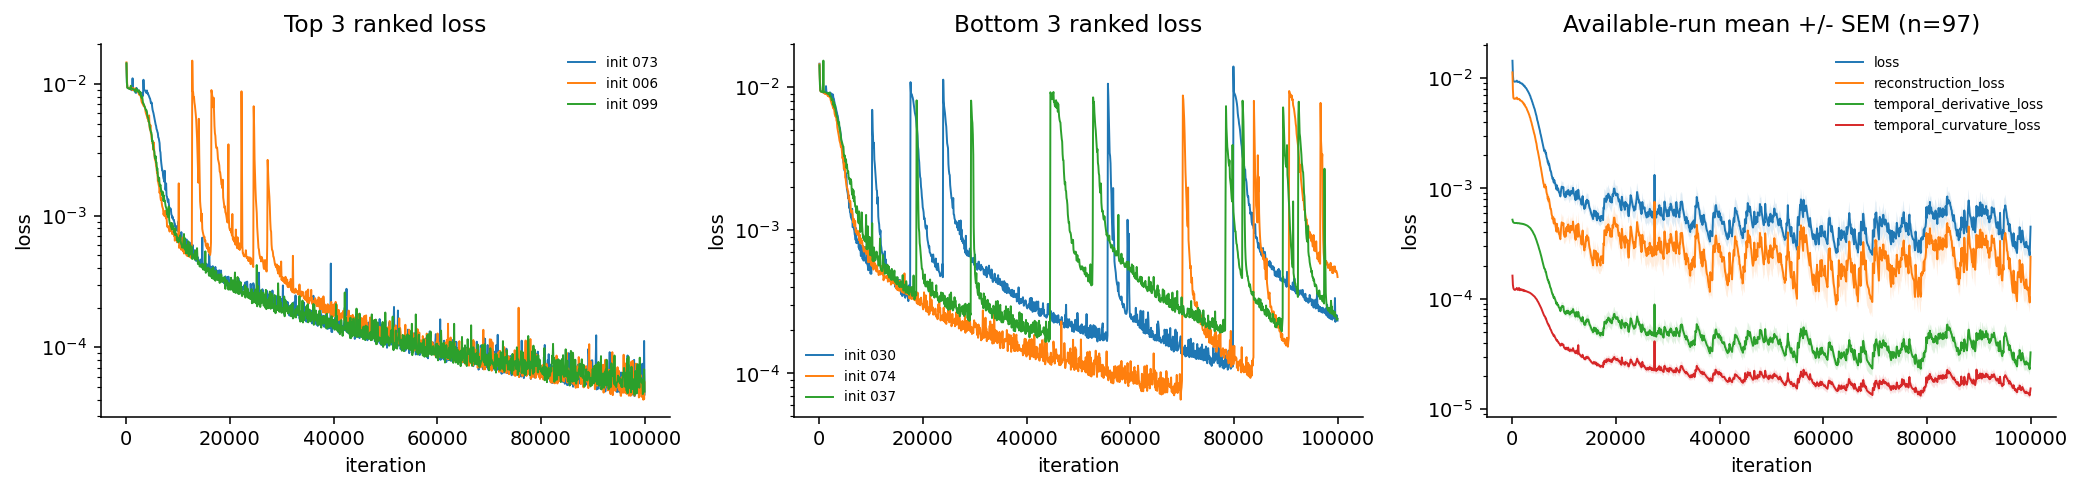

In [6]:
loss_columns = [
    "loss",
    "reconstruction_loss",
    "temporal_derivative_loss",
    "temporal_curvature_loss",
]
plot_history = all_history.copy()
max_points = 1200
stride = max(1, int(np.ceil(plot_history["iteration"].nunique() / max_points)))
plot_history = plot_history[plot_history["iteration"] % stride == 0]

summary = plot_history.groupby("iteration")[loss_columns].agg(["mean", "sem"]).reset_index()
summary.columns = ["iteration"] + [f"{col}_{stat}" for col, stat in summary.columns[1:]]

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), sharex=True)
for _, row in selected_top3.iterrows():
    hist = plot_history[plot_history["init_idx"] == int(row.init_idx)].sort_values("iteration")
    axes[0].plot(hist["iteration"], hist["loss"], linewidth=1.0, label=f"init {int(row.init_idx):03d}")
axes[0].set(title="Top 3 ranked loss", xlabel="iteration", ylabel="loss")
axes[0].set_yscale("log")
axes[0].legend(frameon=False, fontsize=7)

for _, row in selected_bottom3.iterrows():
    hist = plot_history[plot_history["init_idx"] == int(row.init_idx)].sort_values("iteration")
    axes[1].plot(hist["iteration"], hist["loss"], linewidth=1.0, label=f"init {int(row.init_idx):03d}")
axes[1].set(title="Bottom 3 ranked loss", xlabel="iteration", ylabel="loss")
axes[1].set_yscale("log")
axes[1].legend(frameon=False, fontsize=7)

for column in loss_columns:
    x = summary["iteration"].to_numpy(dtype=float)
    mean = summary[f"{column}_mean"].to_numpy(dtype=float)
    sem = summary[f"{column}_sem"].fillna(0.0).to_numpy(dtype=float)
    axes[2].plot(x, mean, linewidth=1.0, label=column)
    axes[2].fill_between(x, mean - sem, mean + sem, alpha=0.14)
axes[2].set(title=f"Available-run mean +/- SEM (n={len(complete)})", xlabel="iteration", ylabel="loss")
axes[2].set_yscale("log")
axes[2].legend(frameon=False, fontsize=7)
fig.tight_layout()

## 7. Detailed Review Helpers

In [7]:
condition_colors = {
    "face_interactive": "#b64198",
    "face_non_interactive": "#4c9a2a",
    "object": "#6f4e37",
}
region_colors = {
    "ofc": "#4c78a8",
    "bla": "#f58518",
    "dmpfc": "#54a24b",
    "accg": "#e45756",
}

replay_cache = {}
within_projection_cache = {}


def load_ranked_replay(init_idx):
    init_idx = int(init_idx)
    if init_idx not in replay_cache:
        run_dir = Path(model_rank.loc[model_rank["init_idx"] == init_idx, "run_dir"].iloc[0])
        replay_cache[init_idx] = replay_fixation_mrnn_run(run_dir, device="cpu")
    return replay_cache[init_idx]

reference_replay = load_ranked_replay(best_init_idx)
condition_order = tuple(reference_replay["condition_order"])
region_order = tuple(reference_replay["region_order"])
rng = np.random.default_rng()
diagnostic_region = str(rng.choice(region_order))
target_fr_by_region = targets.pc_reconstructed_raw_by_region()
n_units = target_fr_by_region[diagnostic_region].shape[-1]
diagnostic_unit_indices = np.sort(rng.choice(n_units, size=min(6, n_units), replace=False))


def model_fit_quality_table(selection):
    rows = []
    for _, model_row in selection.iterrows():
        replay = load_ranked_replay(model_row.init_idx)
        metrics = pd.concat(
            [
                reconstruction_accuracy(replay).assign(metric_space="region_pcs"),
                pc_reconstructed_firing_rate_accuracy(replay).assign(metric_space="backprojected_fr"),
            ],
            ignore_index=True,
        )
        metric_summary = metrics.groupby("metric_space", as_index=False).agg(
            mean_mse=("mse", "mean"),
            mean_mae=("mae", "mean"),
            mean_r2=("r2", "mean"),
            mean_corr=("correlation", "mean"),
        )
        for metric_row in metric_summary.itertuples(index=False):
            rows.append(
                {
                    "init_idx": int(model_row.init_idx),
                    "seed": int(model_row.seed),
                    "metric_space": metric_row.metric_space,
                    "final_loss": float(model_row.final_loss),
                    "n_loss_transients": int(model_row.n_loss_transients),
                    "transient_penalty": float(model_row.transient_penalty),
                    "latest_transient_iteration": model_row.latest_transient_iteration,
                    "fit_quality_score": float(model_row.fit_quality_score),
                    "mean_mse": float(metric_row.mean_mse),
                    "mean_mae": float(metric_row.mean_mae),
                    "mean_r2": float(metric_row.mean_r2),
                    "mean_corr": float(metric_row.mean_corr),
                }
            )
    return pd.DataFrame(rows)


def plot_selected_loss_trajectories(selection, title):
    fig, ax = plt.subplots(figsize=(7.8, 3.4))
    for _, model_row in selection.iterrows():
        hist = all_history[all_history["init_idx"] == int(model_row.init_idx)].sort_values("iteration")
        ax.plot(
            hist["iteration"],
            hist["loss"],
            linewidth=1.1,
            label=f"init {int(model_row.init_idx):03d}; score {float(model_row.fit_quality_score):.2f}",
        )
        detected = detect_loss_transients(hist)
        transient_idx = detected["transient_idx"]
        if transient_idx.size:
            ax.scatter(
                detected["iterations"][transient_idx],
                detected["losses"][transient_idx],
                s=14,
                alpha=0.75,
            )
    ax.set(title=title, xlabel="iteration", ylabel="loss")
    ax.set_yscale("log")
    ax.legend(frameon=False, fontsize=7)
    fig.tight_layout()
    return fig, ax


def plot_pc_and_fr_reconstruction_for_model(model_row, *, region=diagnostic_region):
    replay = load_ranked_replay(model_row.init_idx)
    predicted_fr = backproject_replay_outputs_to_firing_rates(replay)[region]
    n_pcs = min(4, targets.pcs_by_region[region].shape[-1])
    fig, axes = plt.subplots(n_pcs, len(condition_order), figsize=(3.0 * len(condition_order), 1.65 * n_pcs), sharex=True, squeeze=False)
    for pc_idx in range(n_pcs):
        for cond_col, condition in enumerate(condition_order):
            ax = axes[pc_idx, cond_col]
            cond_idx = condition_order.index(condition)
            ax.plot(timeline, targets.pcs_by_region[region][cond_idx, :, pc_idx], color="black", linewidth=1.7, label="target")
            yhat = replay["output_by_region"][region].detach().cpu().numpy()[cond_idx, :, pc_idx]
            ax.plot(timeline, yhat, color="#2f6fbb", linewidth=1.0, label="model")
            ax.axvline(0.0, color="0.5", linewidth=0.6)
            if pc_idx == 0:
                ax.set_title(condition, fontsize=8)
            if cond_col == 0:
                ax.set_ylabel(f"PC{pc_idx + 1}")
            if pc_idx == n_pcs - 1:
                ax.set_xlabel("time (s)")
    axes[0, -1].legend(frameon=False, fontsize=7)
    fig.suptitle(f"init {int(model_row.init_idx):03d}; region {region}; PC reconstruction", y=1.02)
    fig.tight_layout()

    fig_fr, axes_fr = plt.subplots(len(diagnostic_unit_indices), len(condition_order), figsize=(3.0 * len(condition_order), 1.55 * len(diagnostic_unit_indices)), sharex=True, squeeze=False)
    for row_idx, unit_idx in enumerate(diagnostic_unit_indices):
        for cond_col, condition in enumerate(condition_order):
            ax = axes_fr[row_idx, cond_col]
            cond_idx = condition_order.index(condition)
            ax.plot(timeline, target_fr_by_region[region][cond_idx, :, unit_idx], color="black", linewidth=1.7, label="target")
            ax.plot(timeline, predicted_fr[cond_idx, :, unit_idx], color="#2f6fbb", linewidth=1.0, label="model")
            ax.axvline(0.0, color="0.5", linewidth=0.6)
            if row_idx == 0:
                ax.set_title(condition, fontsize=8)
            if cond_col == 0:
                ax.set_ylabel(f"unit {unit_idx}")
            if row_idx == len(diagnostic_unit_indices) - 1:
                ax.set_xlabel("time (s)")
    axes_fr[0, -1].legend(frameon=False, fontsize=7)
    fig_fr.suptitle(f"init {int(model_row.init_idx):03d}; region {region}; backprojected FR", y=1.02)
    fig_fr.tight_layout()
    return (fig, axes), (fig_fr, axes_fr)


def _region_slice(replay, region):
    start, stop = replay["model"].mrnn.get_region_indices(region)
    return slice(int(start), int(stop))


def _latent_arrays(replay, latent, region):
    sl = _region_slice(replay, region)
    conditions = tuple(replay["condition_order"])
    hidden = np.stack([latent[condition]["hidden_state"][:, sl].numpy() for condition in conditions], axis=0)
    drive = np.stack([latent[condition]["recurrent_drive"][:, sl].numpy() for condition in conditions], axis=0)
    return hidden, drive


def within_condition_projection_table_for_replay(replay, init_idx, seed):
    latent = extract_fixation_latent_dynamics(replay)
    current_vectors = extract_region_current_vectors(replay)
    conditions = tuple(replay["condition_order"])
    regions = tuple(replay["region_order"])
    rows = []
    for active_condition in conditions:
        active_idx = conditions.index(active_condition)
        for target_region in regions:
            hidden, drive = _latent_arrays(replay, latent, target_region)
            direction = drive[active_idx] - hidden[active_idx]
            norm = np.linalg.norm(direction, axis=-1)
            unit_direction = np.divide(
                direction,
                np.maximum(norm[:, None], 1e-8),
                out=np.zeros_like(direction),
                where=norm[:, None] > 1e-8,
            )
            source_projections = {}
            for source_region in regions:
                current = current_vectors[(source_region, target_region)].numpy()[active_idx]
                source_projections[source_region] = np.sum(current * unit_direction, axis=-1)
            denom = np.sum([np.abs(values) for values in source_projections.values()], axis=0)
            denom = np.where(denom > 1e-8, denom, 1.0)
            for source_region, projection in source_projections.items():
                relative_projection = projection / denom
                for time_idx, value in enumerate(projection):
                    rows.append(
                        {
                            "init_idx": int(init_idx),
                            "seed": int(seed),
                            "active_condition": active_condition,
                            "source_region": source_region,
                            "target_region": target_region,
                            "time_idx": int(time_idx),
                            "time_s": float(timeline[time_idx]),
                            "projection": float(value),
                            "relative_projection": float(relative_projection[time_idx]),
                        }
                    )
    return pd.DataFrame(rows)


def within_projection_for_model(model_row):
    init_idx = int(model_row.init_idx)
    if init_idx not in within_projection_cache:
        replay = load_ranked_replay(init_idx)
        within_projection_cache[init_idx] = within_condition_projection_table_for_replay(replay, init_idx, int(model_row.seed))
    return within_projection_cache[init_idx]


def plot_within_condition_source_contribution_for_model(model_row, value_column="relative_projection"):
    df = within_projection_for_model(model_row)
    fig, axes = plt.subplots(
        len(condition_order),
        len(region_order),
        figsize=(13.0, 8.2),
        squeeze=False,
        sharex=True,
        sharey=value_column == "relative_projection",
    )
    for row_idx, active_condition in enumerate(condition_order):
        for col_idx, target_region in enumerate(region_order):
            ax = axes[row_idx, col_idx]
            subset = df[(df["active_condition"] == active_condition) & (df["target_region"] == target_region)]
            ax.axhline(0.0, color="black", linewidth=0.6, alpha=0.5)
            ax.axvline(0.0, color="0.5", linewidth=0.6, alpha=0.45)
            for source_region in region_order:
                trace = subset[subset["source_region"] == source_region].sort_values("time_idx")
                x = trace["time_s"].to_numpy(dtype=float)
                y = trace[value_column].to_numpy(dtype=float)
                color = region_colors.get(source_region, "0.3")
                ax.plot(x, y, color=color, linewidth=1.0, label=source_region)
                ax.fill_between(x, 0.0, y, color=color, alpha=0.12)
            if row_idx == 0:
                ax.set_title(f"target {target_region}", fontsize=9)
            if col_idx == 0:
                ax.set_ylabel(f"{active_condition}\\n{value_column}")
            if row_idx == len(condition_order) - 1:
                ax.set_xlabel("time (s)")
            if value_column == "relative_projection":
                ax.set_ylim(-1.0, 1.0)
    axes[0, -1].legend(frameon=False, fontsize=7, loc="upper left", bbox_to_anchor=(1.02, 1.0))
    fig.suptitle(f"init {int(model_row.init_idx):03d}; within-fixation current contribution", y=1.02)
    fig.tight_layout()
    return fig, axes, df

## 8. Top 3 Models

### 8.1 Loss Trajectory and Fit Quality

,rank,init_idx,seed,final_loss,loss_transient_jump_threshold_log10,n_loss_transients,transient_penalty,latest_transient_iteration,fit_quality_score
0,1,73,448128267,0.000043,0.5,0,0.000000,NaN,-4.364724
1,2,6,216579033,0.000047,0.5,2,0.009597,16413.0,-4.318884
2,3,99,1370089865,0.000054,0.5,1,0.000035,855.0,-4.267171


,init_idx,seed,metric_space,final_loss,n_loss_transients,transient_penalty,latest_transient_iteration,fit_quality_score,mean_mse,mean_mae,mean_r2,mean_corr
0,73,448128267,backprojected_fr,0.000043,0,0.000000,NaN,-4.364724,0.000001,0.000802,0.999973,0.999986
1,73,448128267,region_pcs,0.000043,0,0.000000,NaN,-4.364724,0.000009,0.002208,0.998698,0.999349
2,6,216579033,backprojected_fr,0.000047,2,0.009597,16413.0,-4.318884,0.000002,0.000916,0.999965,0.999982
3,6,216579033,region_pcs,0.000047,2,0.009597,16413.0,-4.318884,0.000011,0.002555,0.998304,0.999160
4,99,1370089865,backprojected_fr,0.000054,1,0.000035,855.0,-4.267171,0.000003,0.001077,0.999954,0.999977
5,99,1370089865,region_pcs,0.000054,1,0.000035,855.0,-4.267171,0.000016,0.003079,0.997995,0.999006


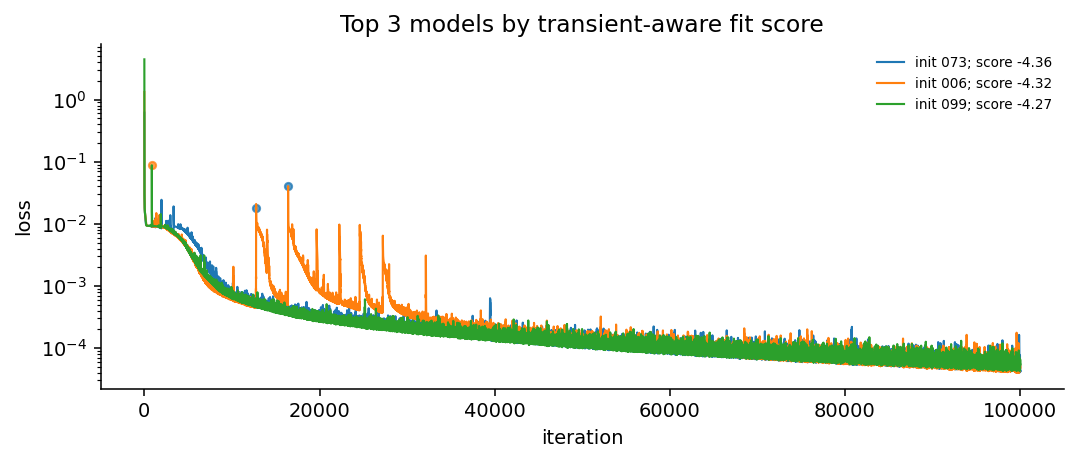

In [8]:
display(selected_top3[["rank", "init_idx", "seed", "final_loss", "loss_transient_jump_threshold_log10", "n_loss_transients", "transient_penalty", "latest_transient_iteration", "fit_quality_score"]])
plot_selected_loss_trajectories(selected_top3, "Top 3 models by transient-aware fit score")
top3_fit_quality = model_fit_quality_table(selected_top3)
display(top3_fit_quality)

### 8.2 PC and Backprojected Firing-Rate Reconstruction

Diagnostic region: ofc; FR units: [12, 17, 37, 41, 116, 221]


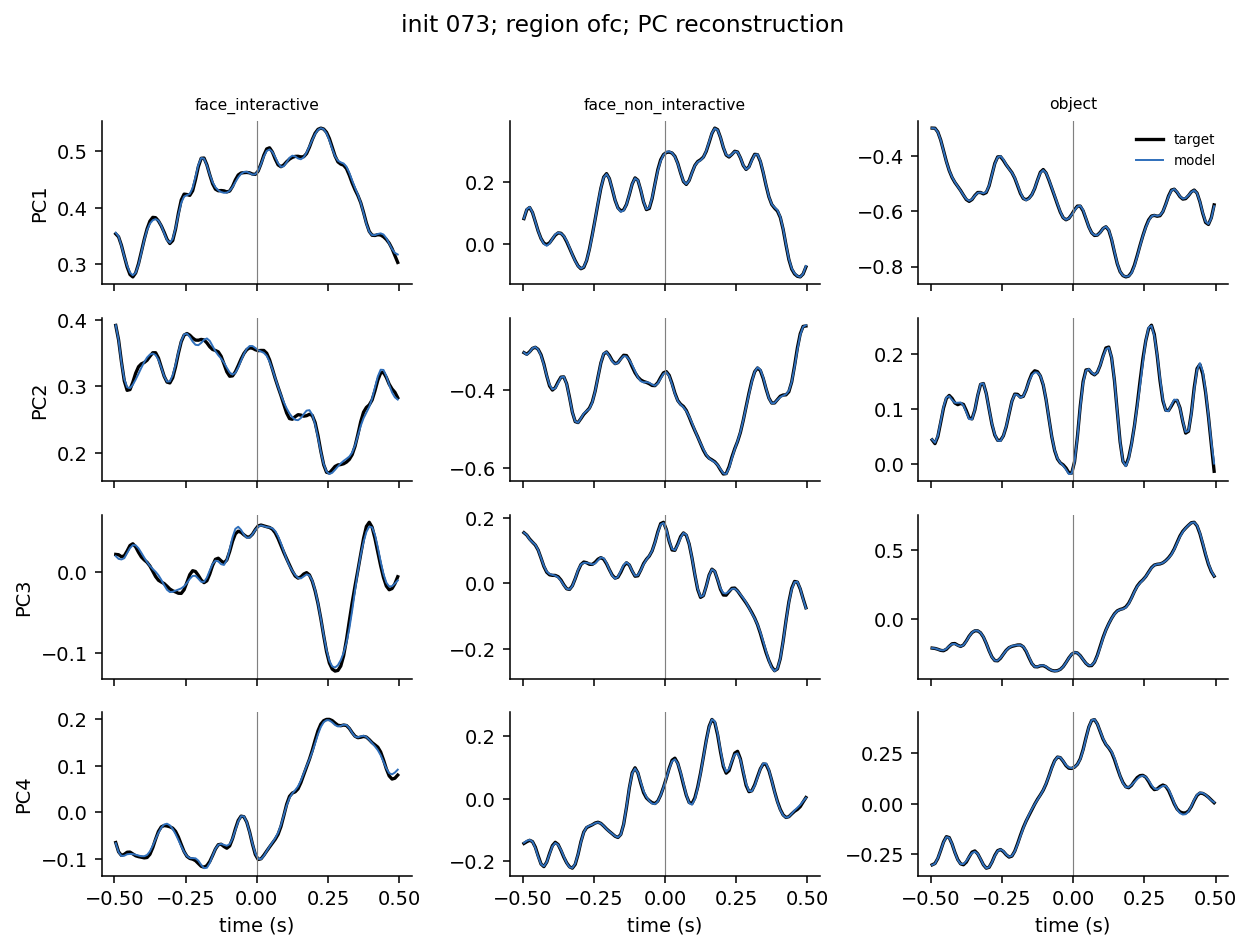

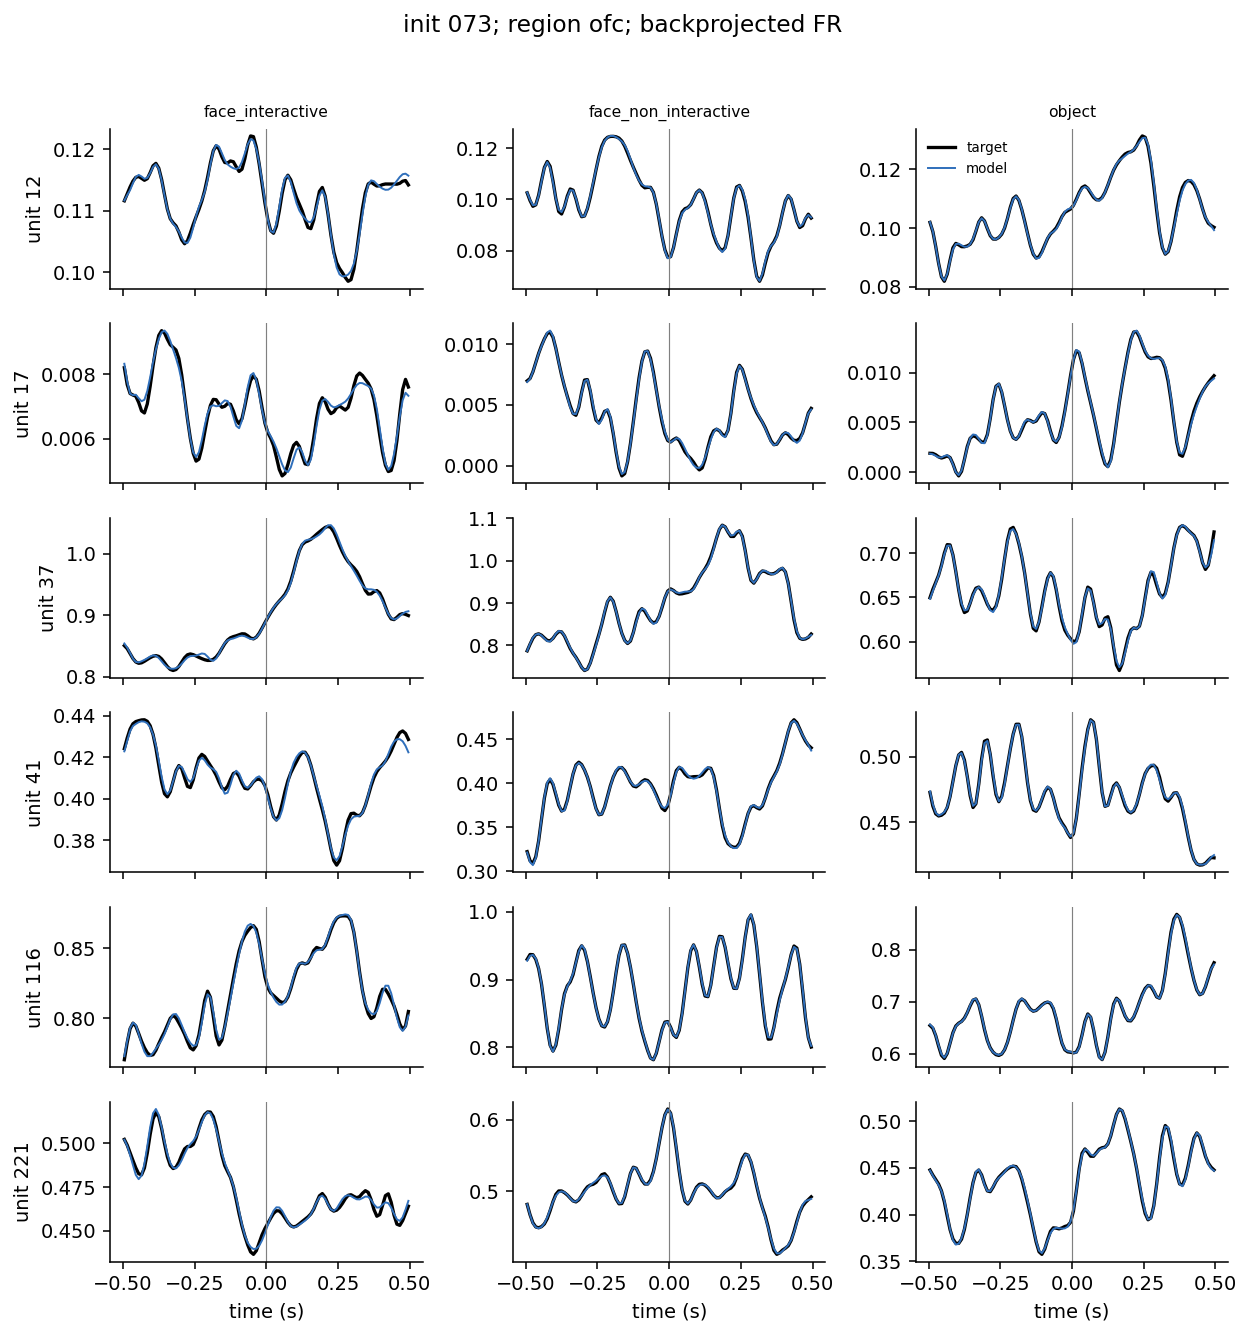

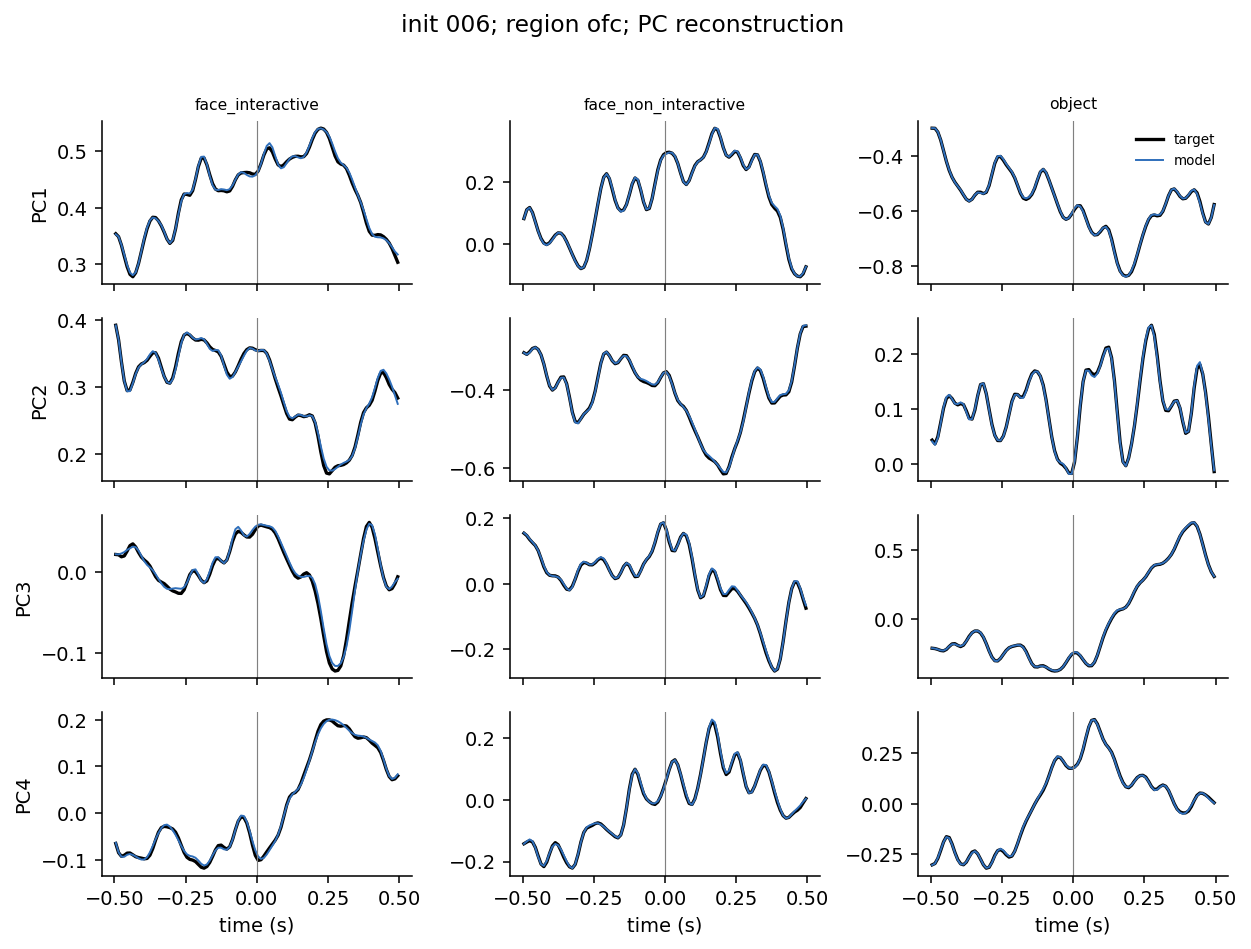

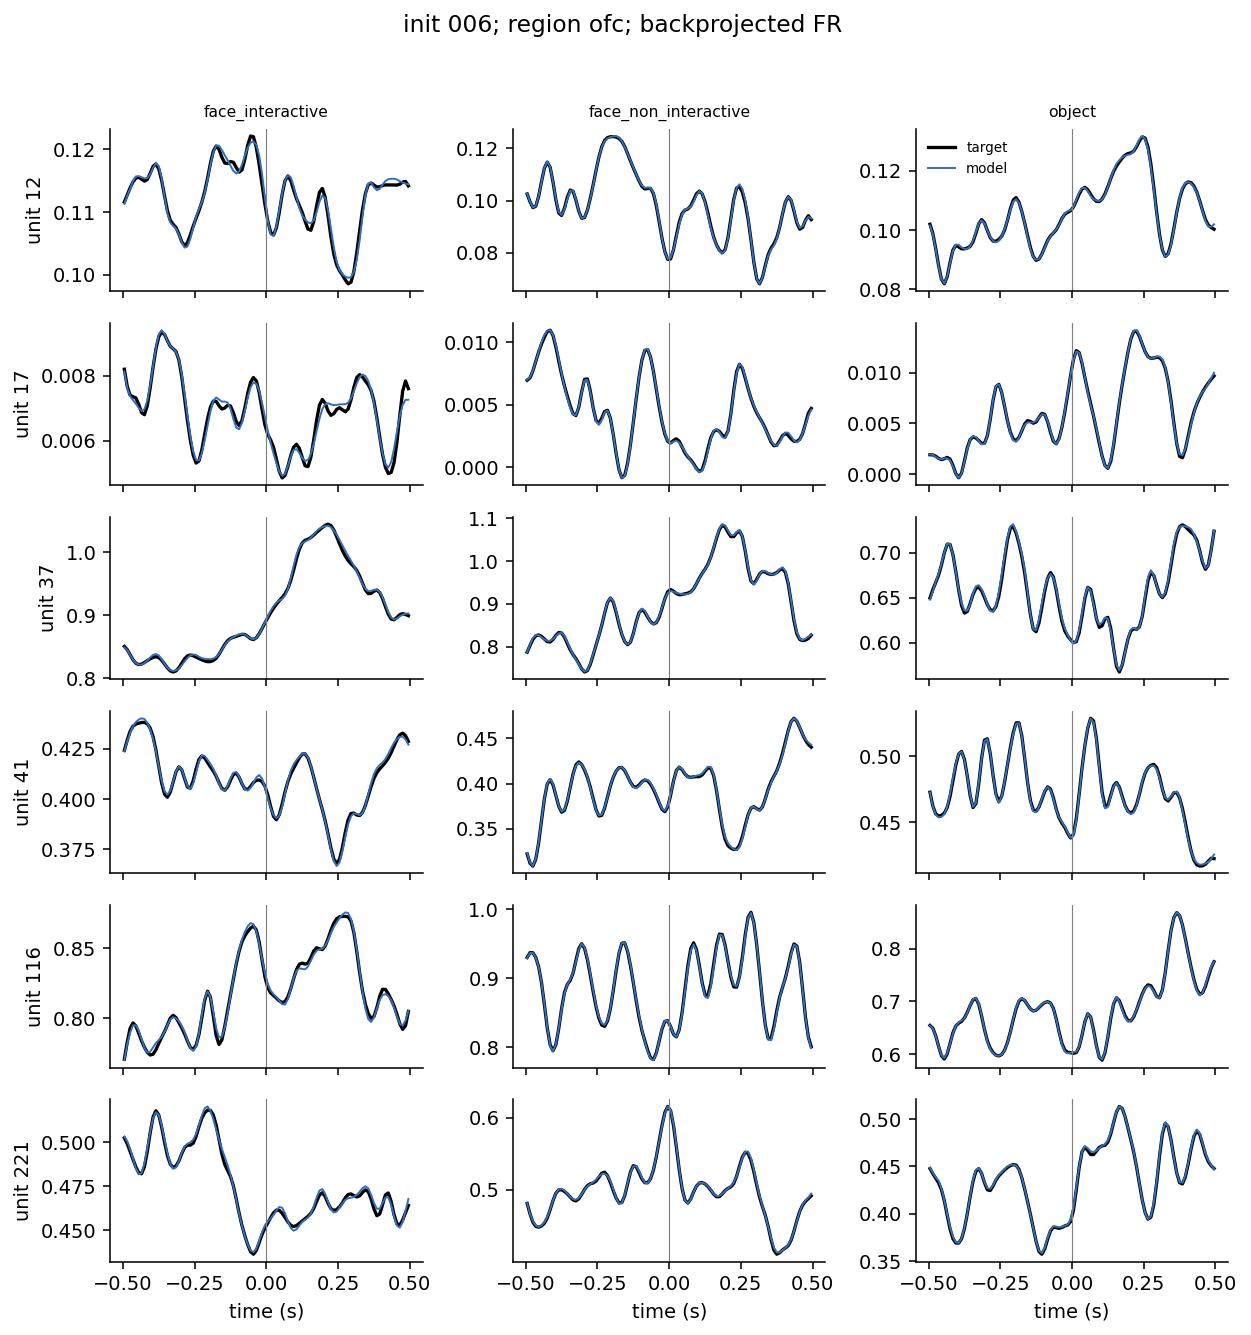

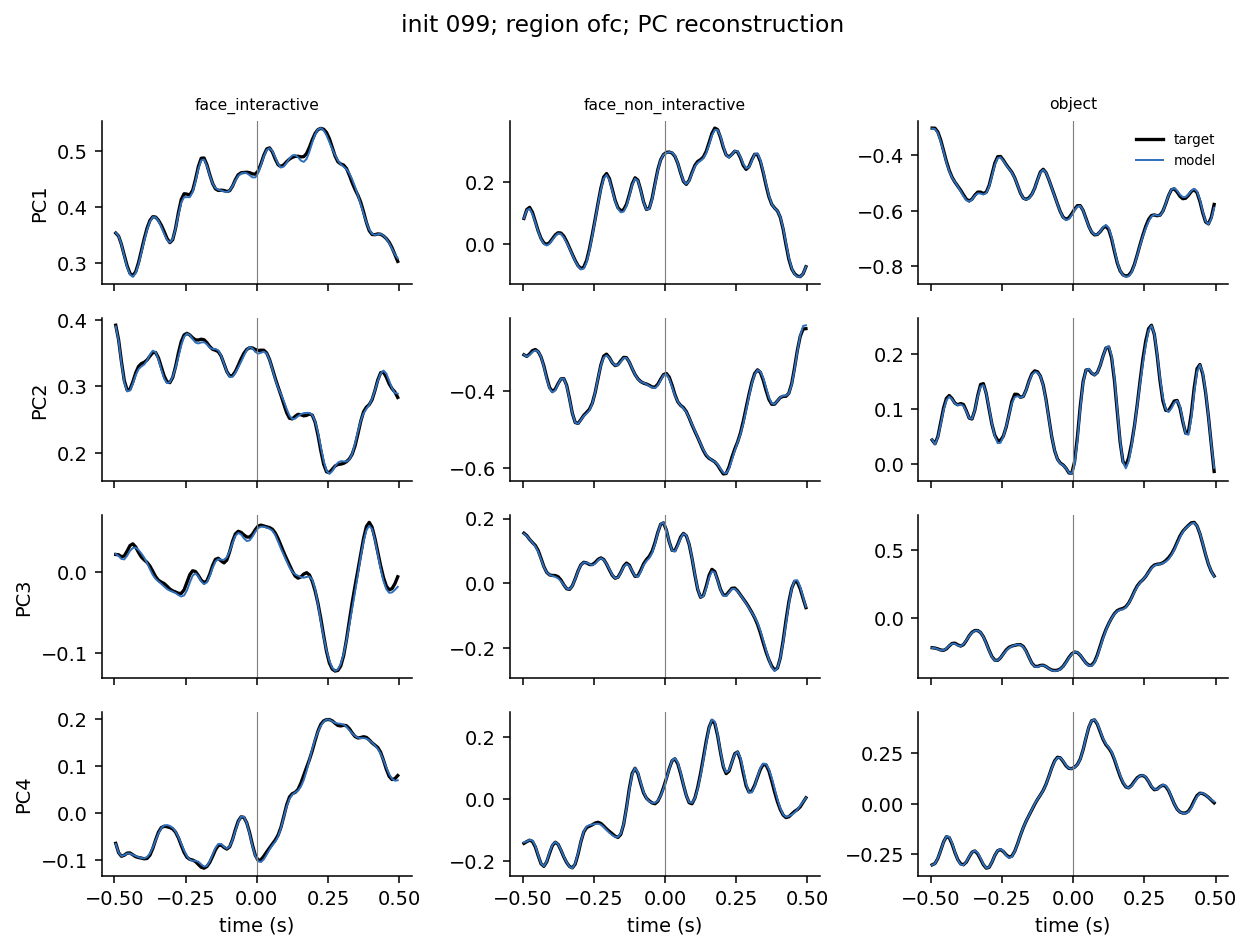

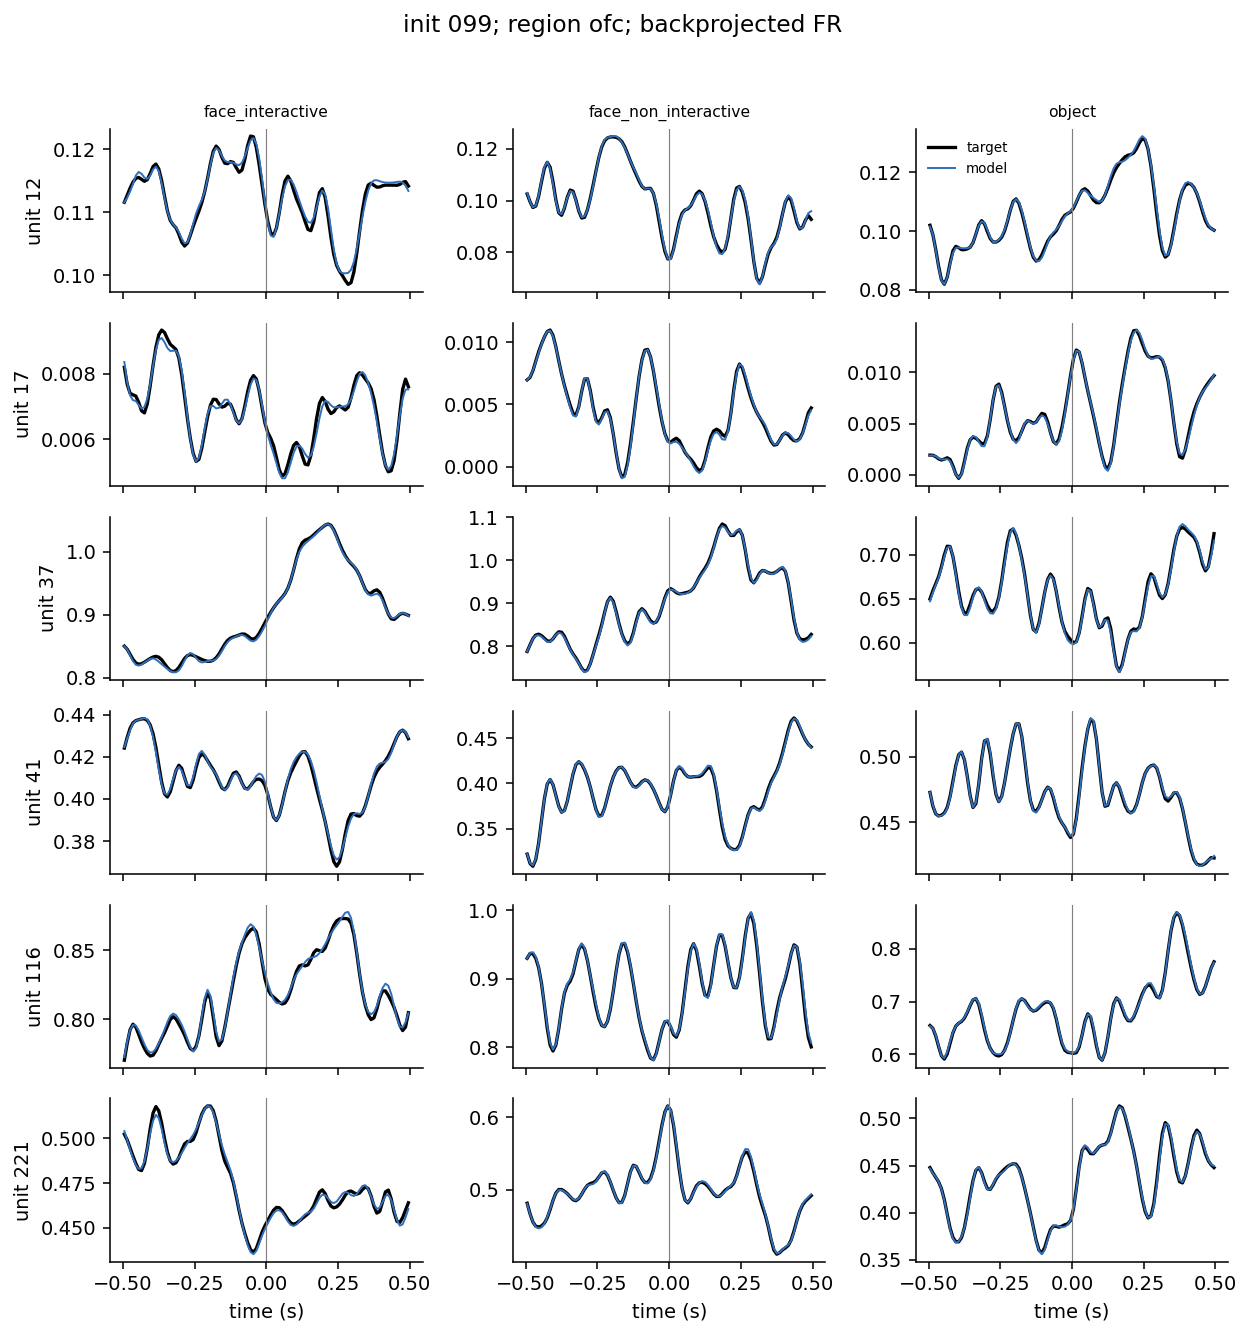

In [9]:
print(f"Diagnostic region: {diagnostic_region}; FR units: {diagnostic_unit_indices.tolist()}")
for _, model_row in selected_top3.iterrows():
    plot_pc_and_fr_reconstruction_for_model(model_row, region=diagnostic_region)

### 8.3 Within-Fixation Current Contribution

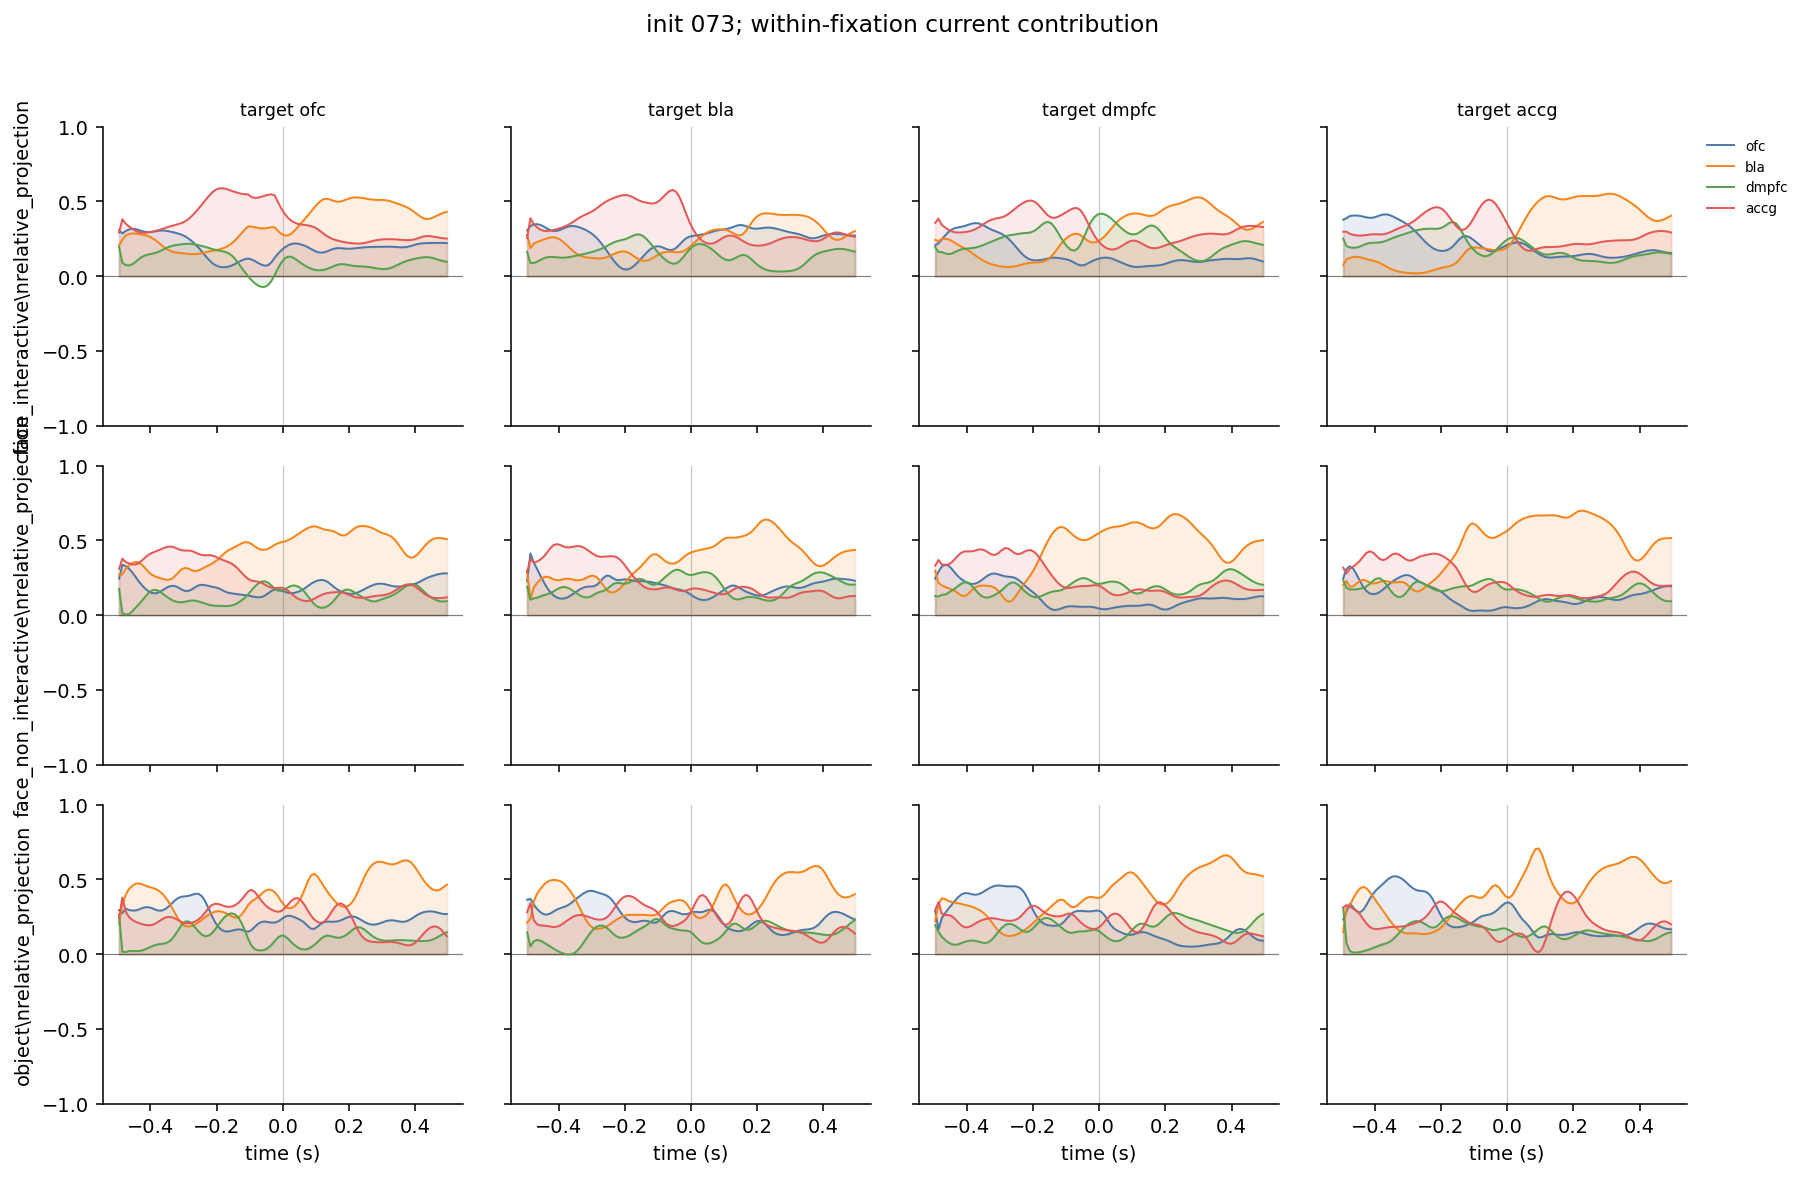

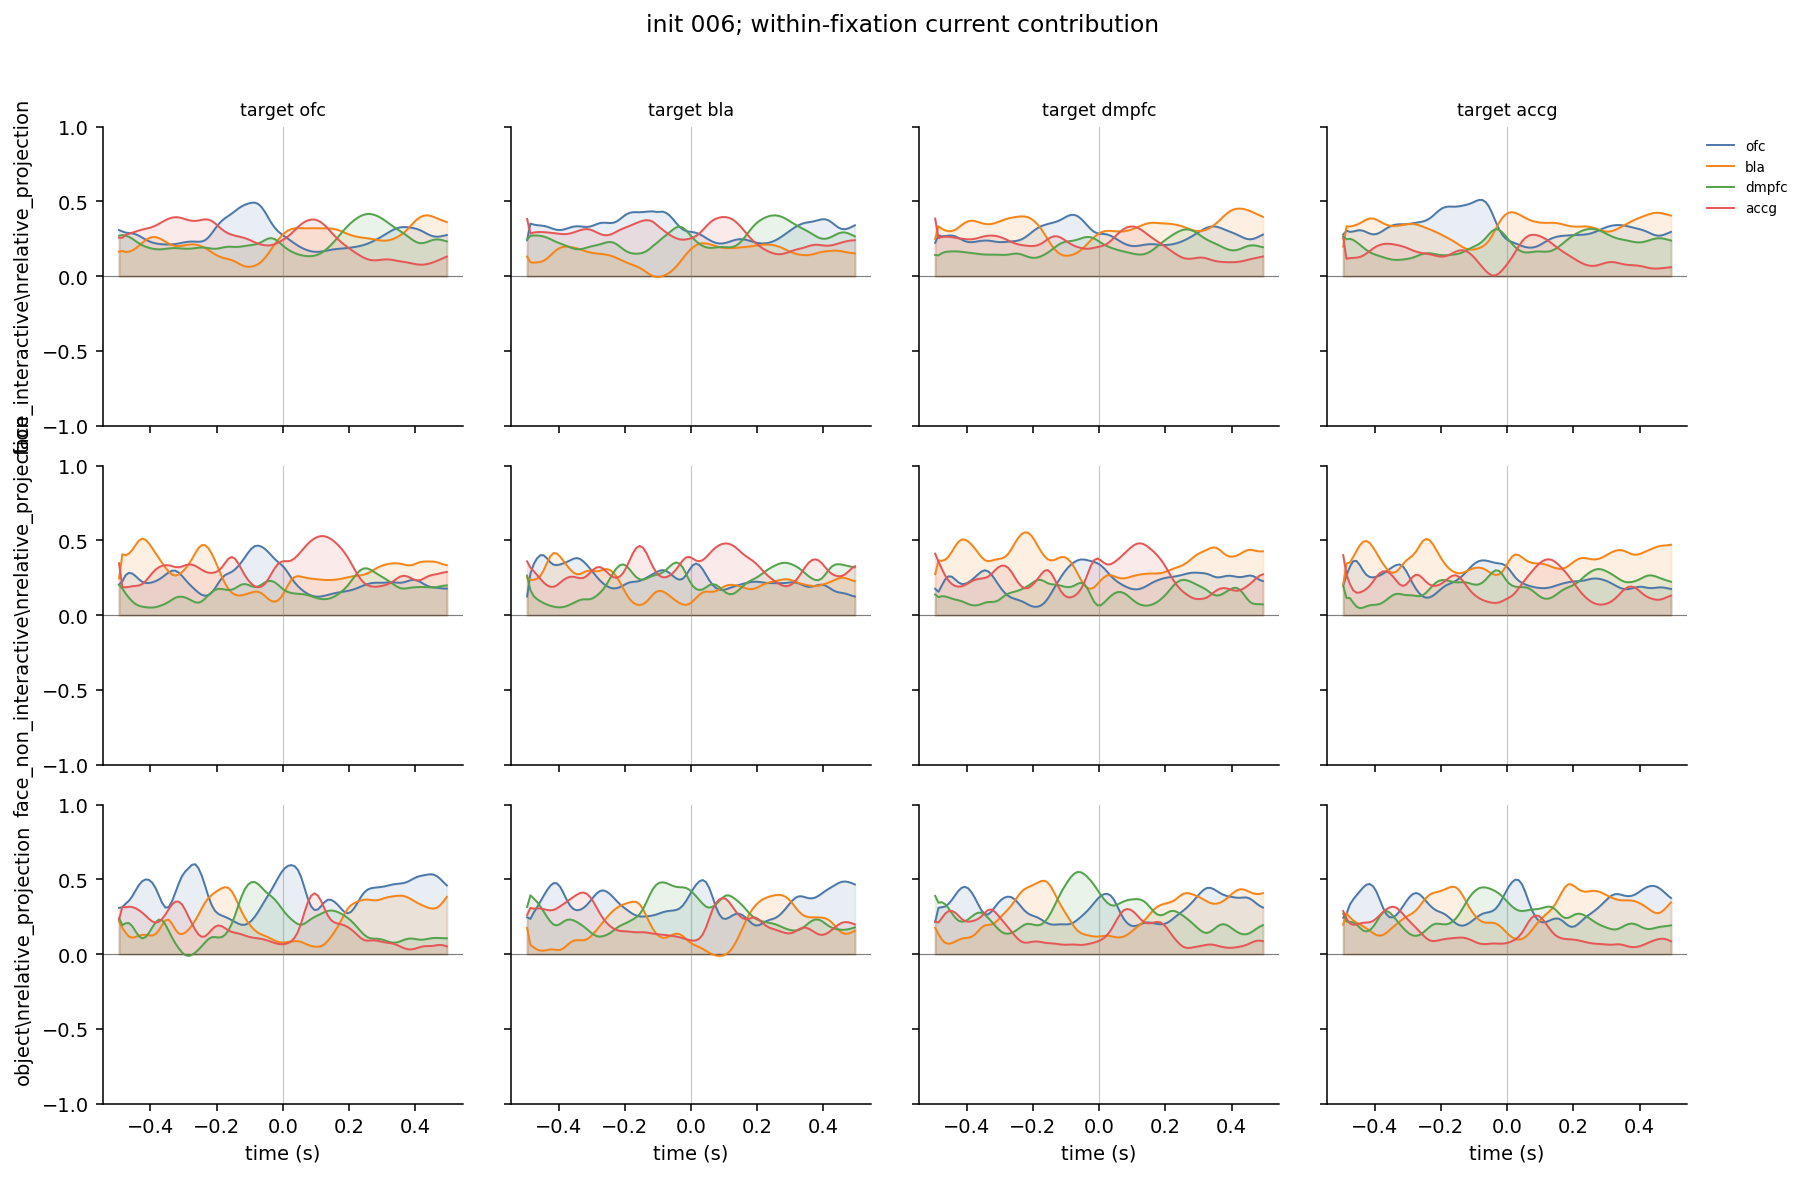

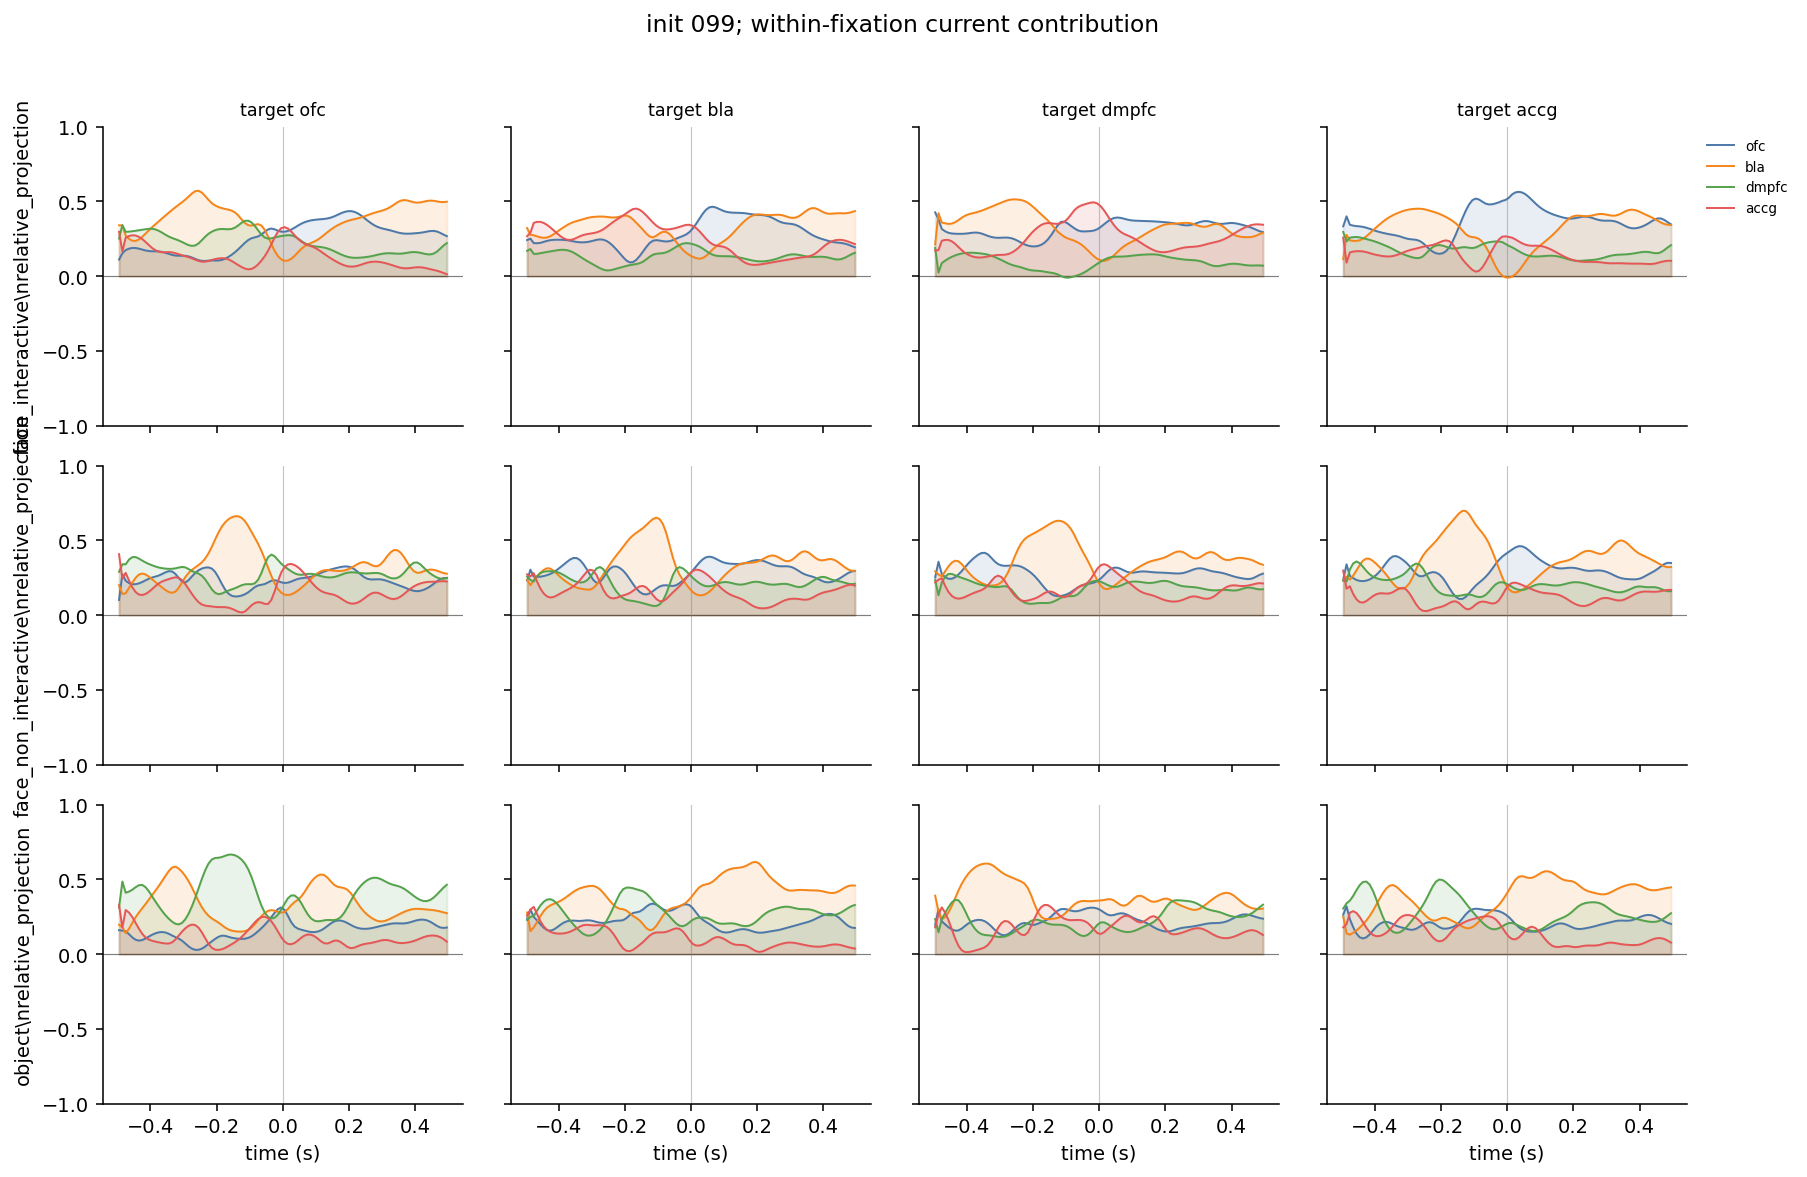

In [10]:
top3_within_projection = {}
for _, model_row in selected_top3.iterrows():
    fig, axes, df = plot_within_condition_source_contribution_for_model(model_row)
    top3_within_projection[int(model_row.init_idx)] = df

## 9. Bottom 3 Models

### 9.1 Loss Trajectory and Fit Quality

,rank,init_idx,seed,final_loss,loss_transient_jump_threshold_log10,n_loss_transients,transient_penalty,latest_transient_iteration,fit_quality_score
96,97,30,1680428869,0.000234,0.5,8,9.091084,79867.0,5.459979
95,96,74,856368863,0.000478,0.5,6,8.723692,96667.0,5.403149
94,95,37,668766115,0.000244,0.5,11,8.801841,92403.0,5.189254


,init_idx,seed,metric_space,final_loss,n_loss_transients,transient_penalty,latest_transient_iteration,fit_quality_score,mean_mse,mean_mae,mean_r2,mean_corr
0,30,1680428869,backprojected_fr,0.000234,8,9.091084,79867.0,5.459979,0.000011,0.002211,0.999799,0.999900
1,30,1680428869,region_pcs,0.000234,8,9.091084,79867.0,5.459979,0.000069,0.006238,0.989760,0.994854
2,74,856368863,backprojected_fr,0.000478,6,8.723692,96667.0,5.403149,0.000031,0.003356,0.999465,0.999733
3,74,856368863,region_pcs,0.000478,6,8.723692,96667.0,5.403149,0.000198,0.009862,0.970178,0.984830
4,37,668766115,backprojected_fr,0.000244,11,8.801841,92403.0,5.189254,0.000011,0.002256,0.999795,0.999897
5,37,668766115,region_pcs,0.000244,11,8.801841,92403.0,5.189254,0.000069,0.006364,0.990392,0.995174


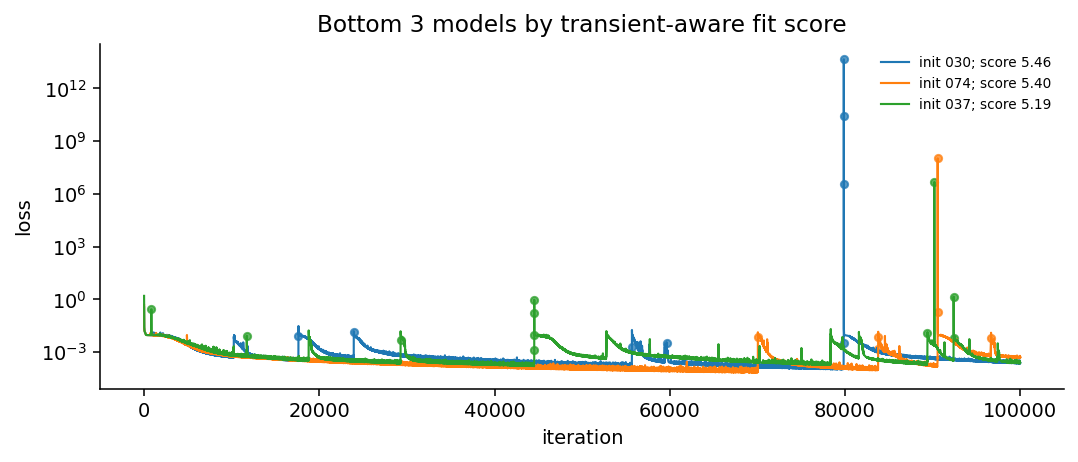

In [11]:
display(selected_bottom3[["rank", "init_idx", "seed", "final_loss", "loss_transient_jump_threshold_log10", "n_loss_transients", "transient_penalty", "latest_transient_iteration", "fit_quality_score"]])
plot_selected_loss_trajectories(selected_bottom3, "Bottom 3 models by transient-aware fit score")
bottom3_fit_quality = model_fit_quality_table(selected_bottom3)
display(bottom3_fit_quality)

### 9.2 PC and Backprojected Firing-Rate Reconstruction

Diagnostic region: ofc; FR units: [12, 17, 37, 41, 116, 221]


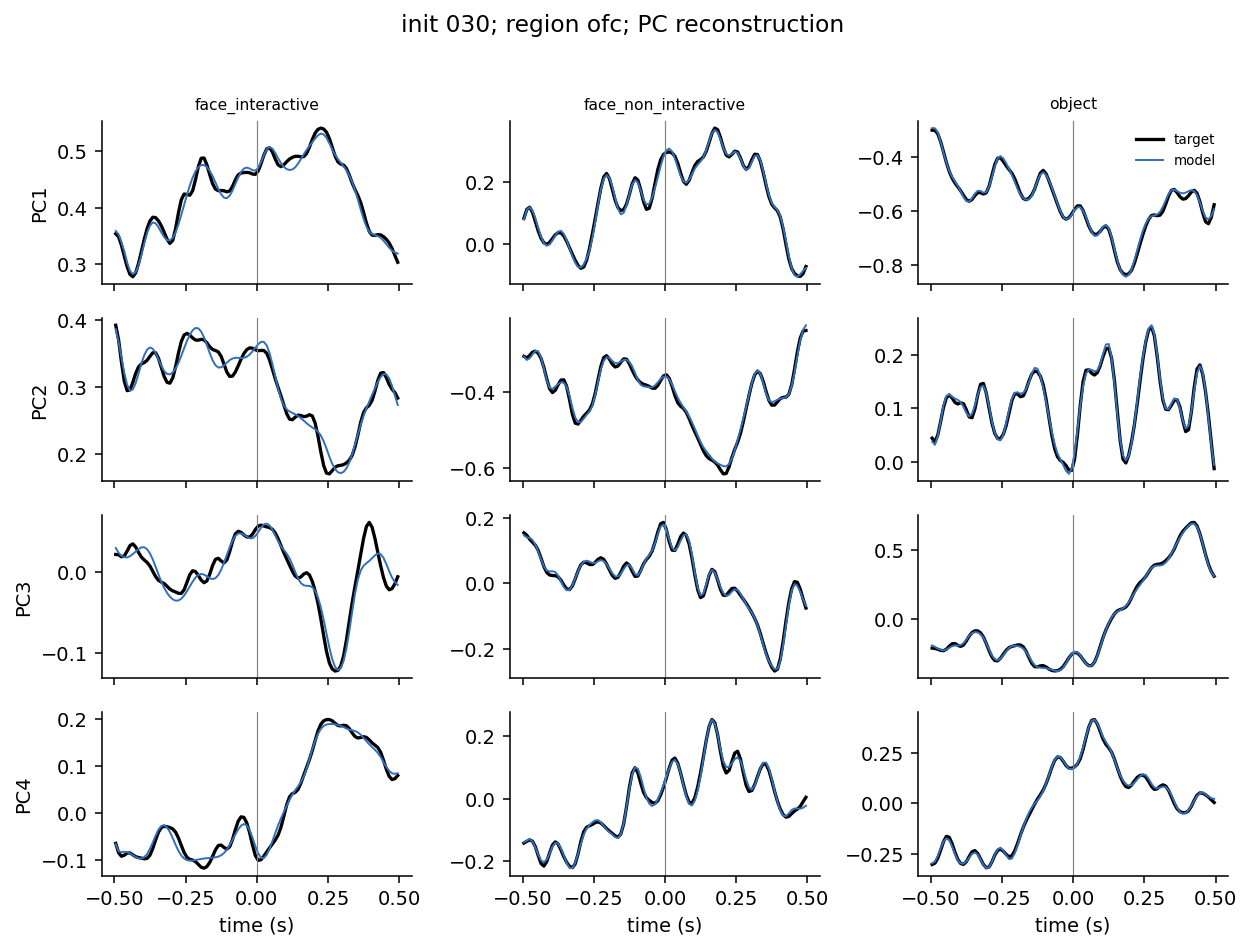

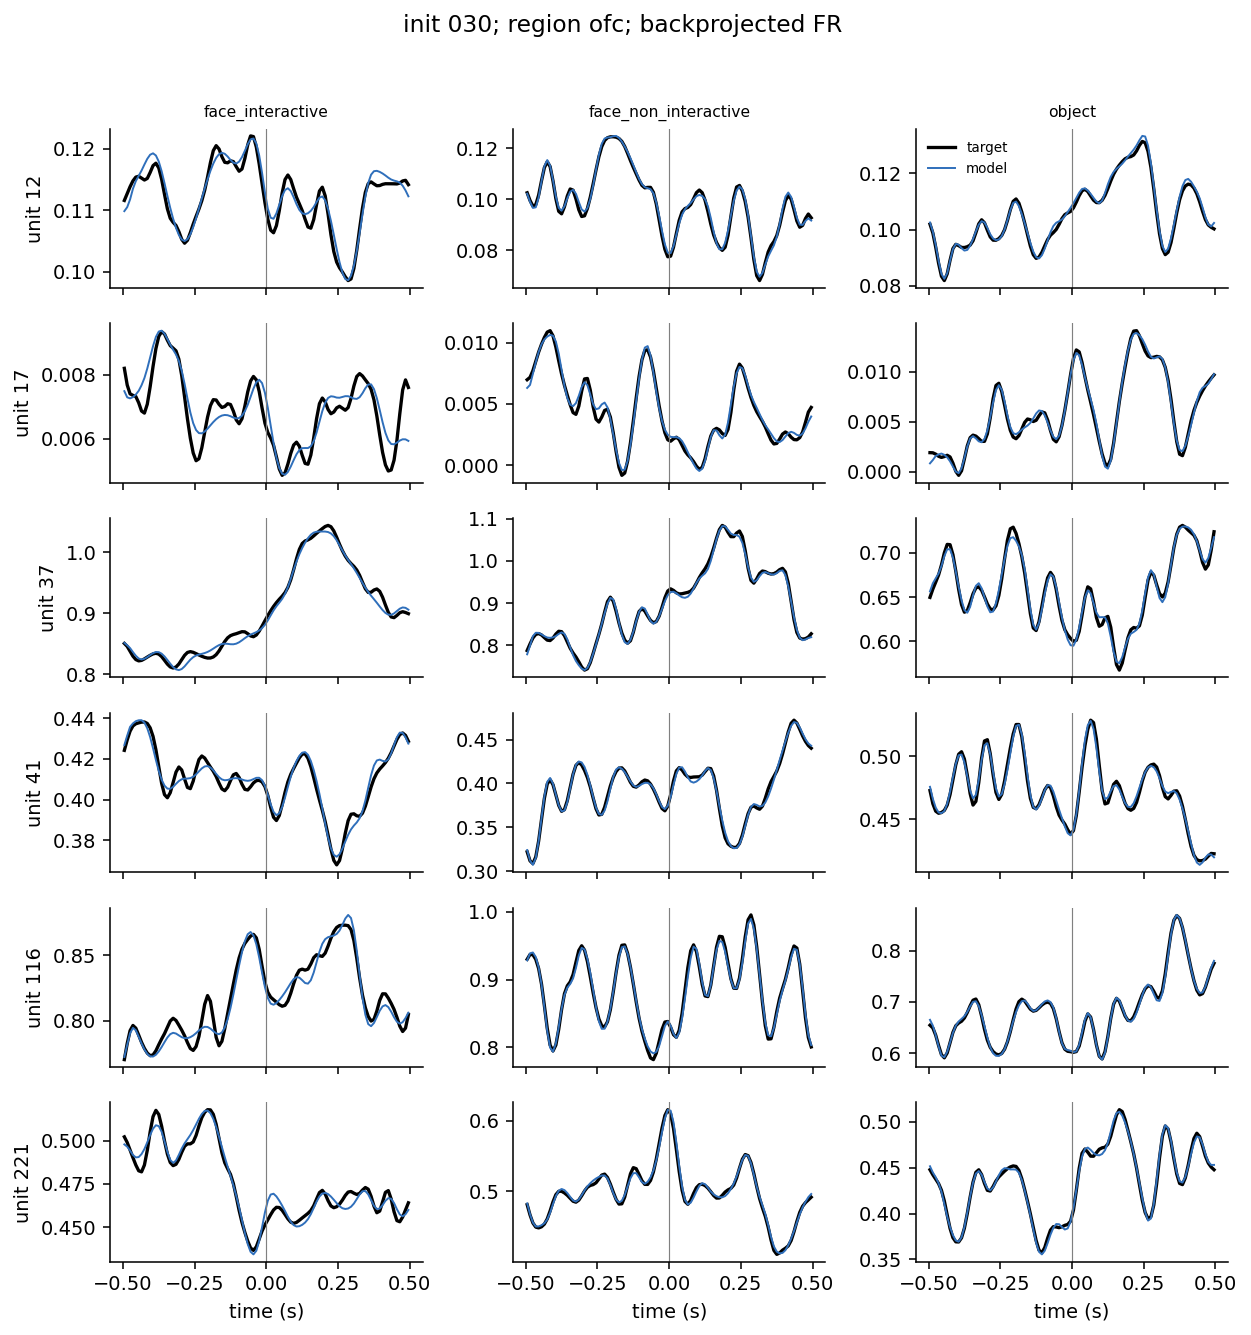

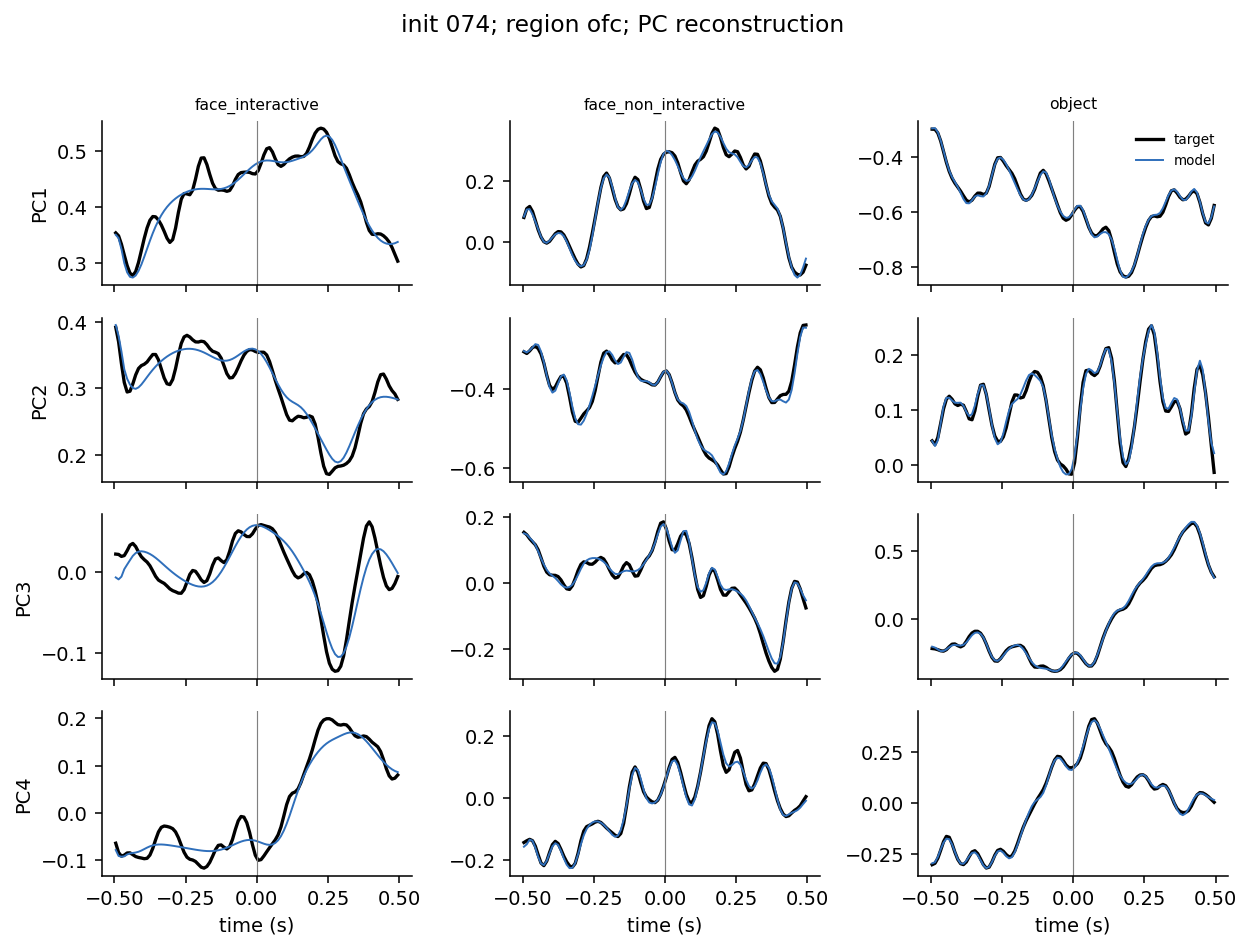

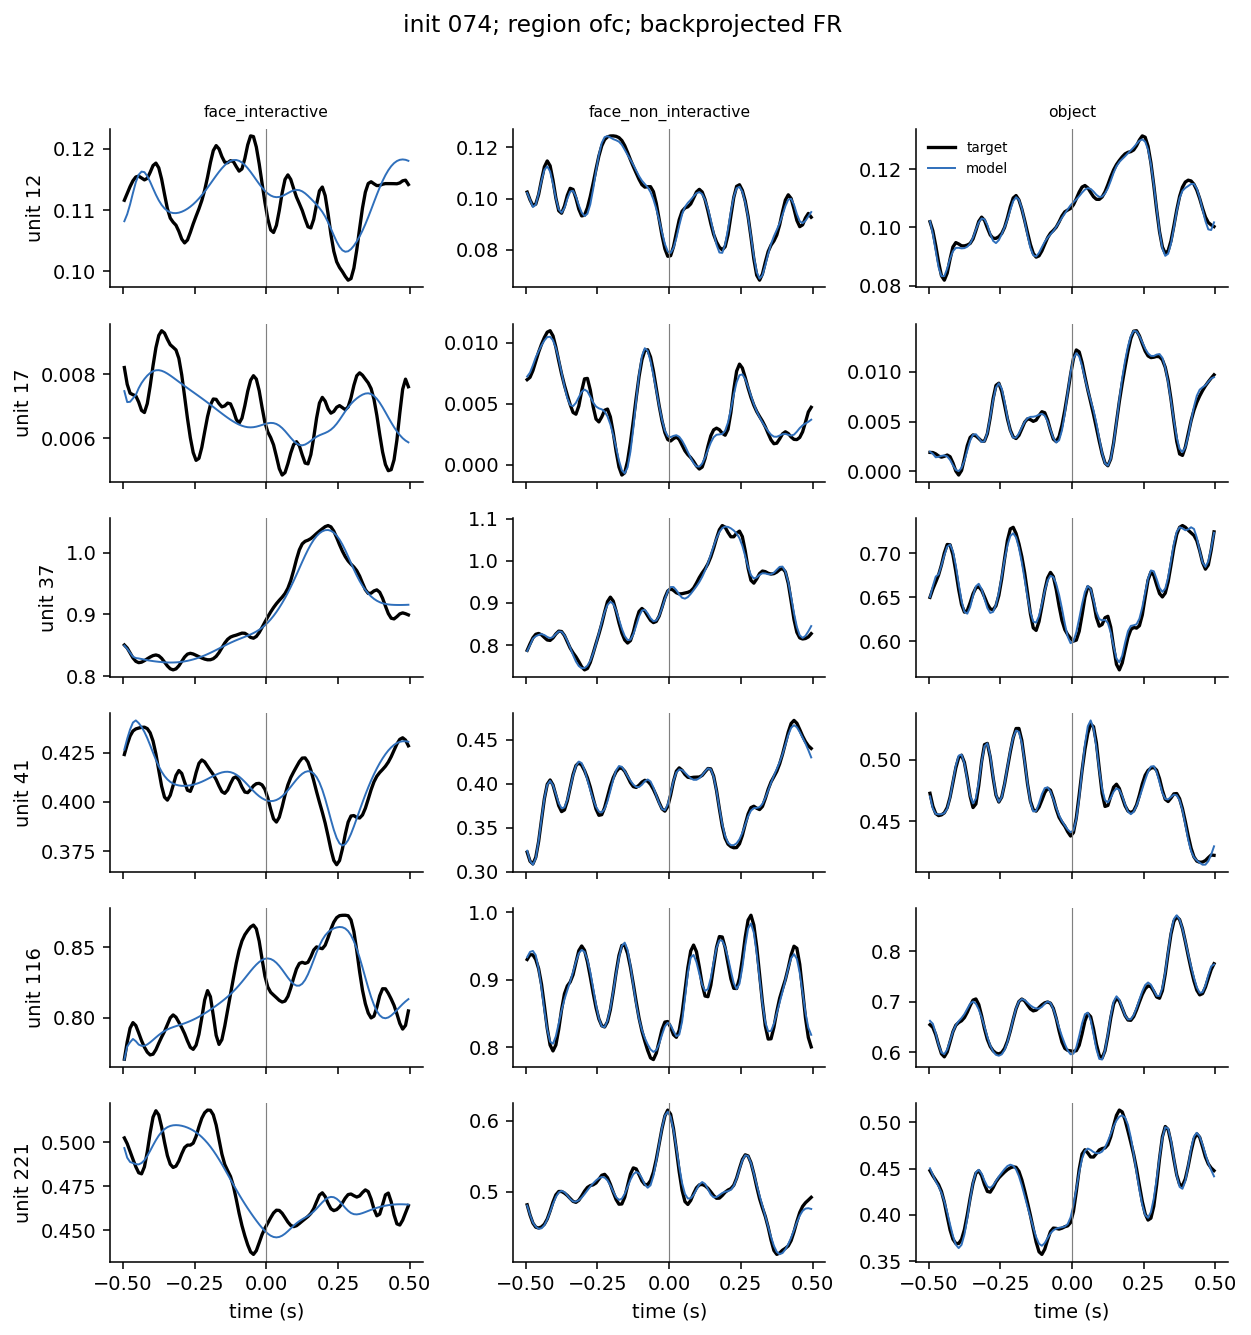

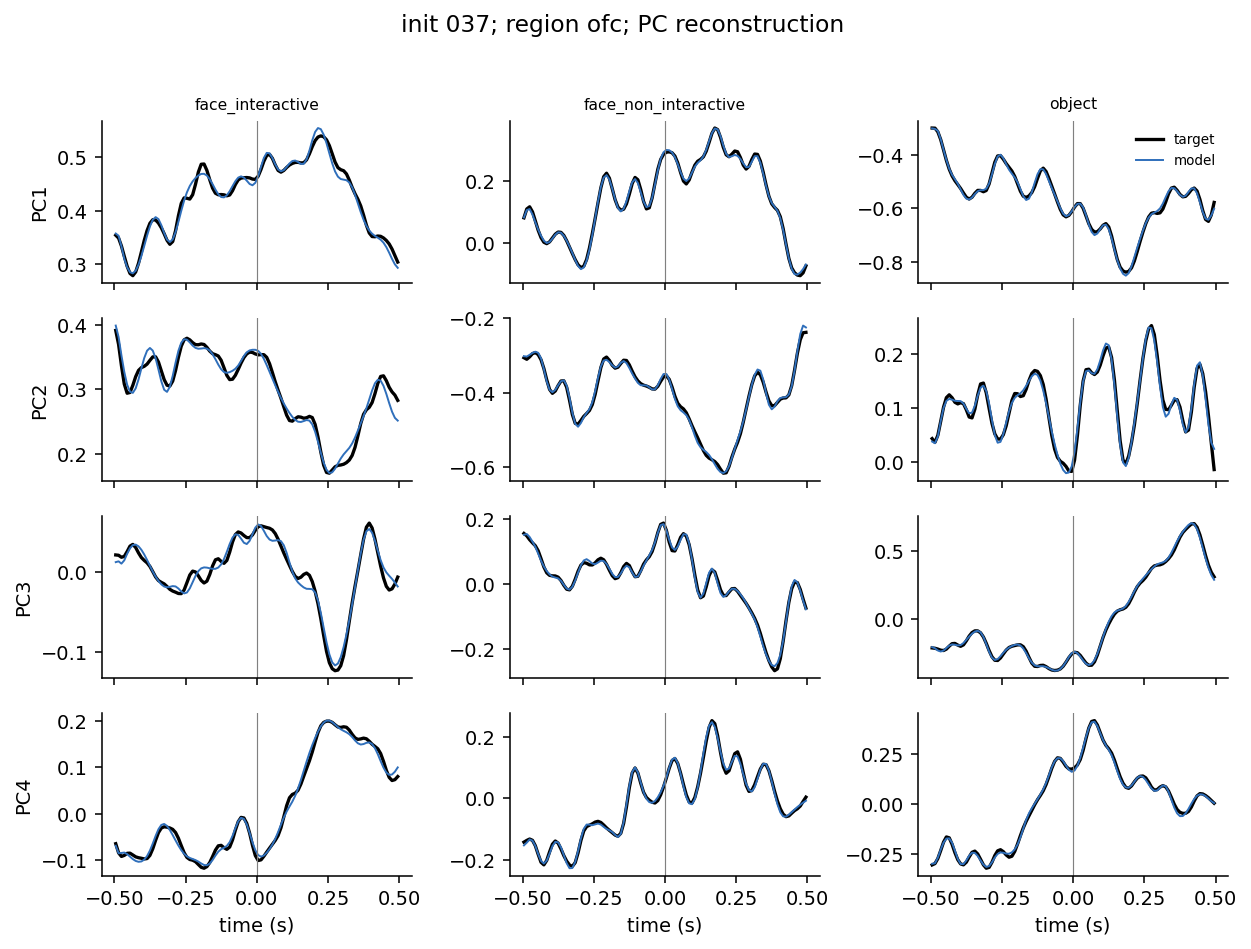

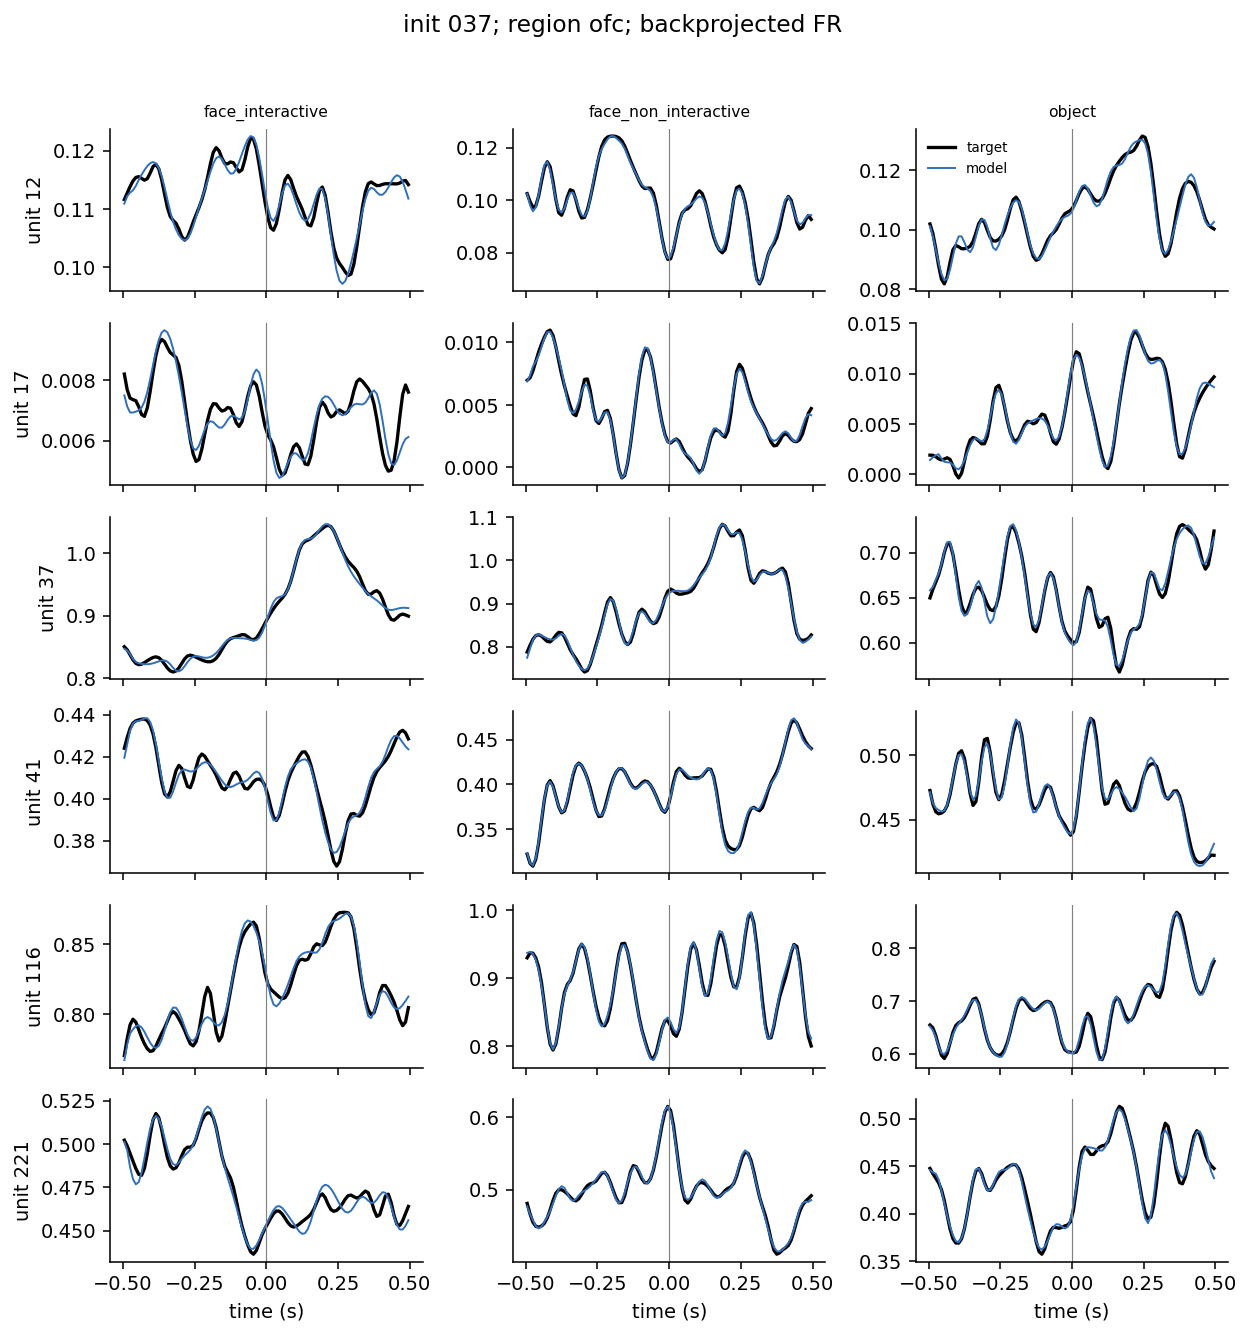

In [12]:
print(f"Diagnostic region: {diagnostic_region}; FR units: {diagnostic_unit_indices.tolist()}")
for _, model_row in selected_bottom3.iterrows():
    plot_pc_and_fr_reconstruction_for_model(model_row, region=diagnostic_region)

### 9.3 Within-Fixation Current Contribution

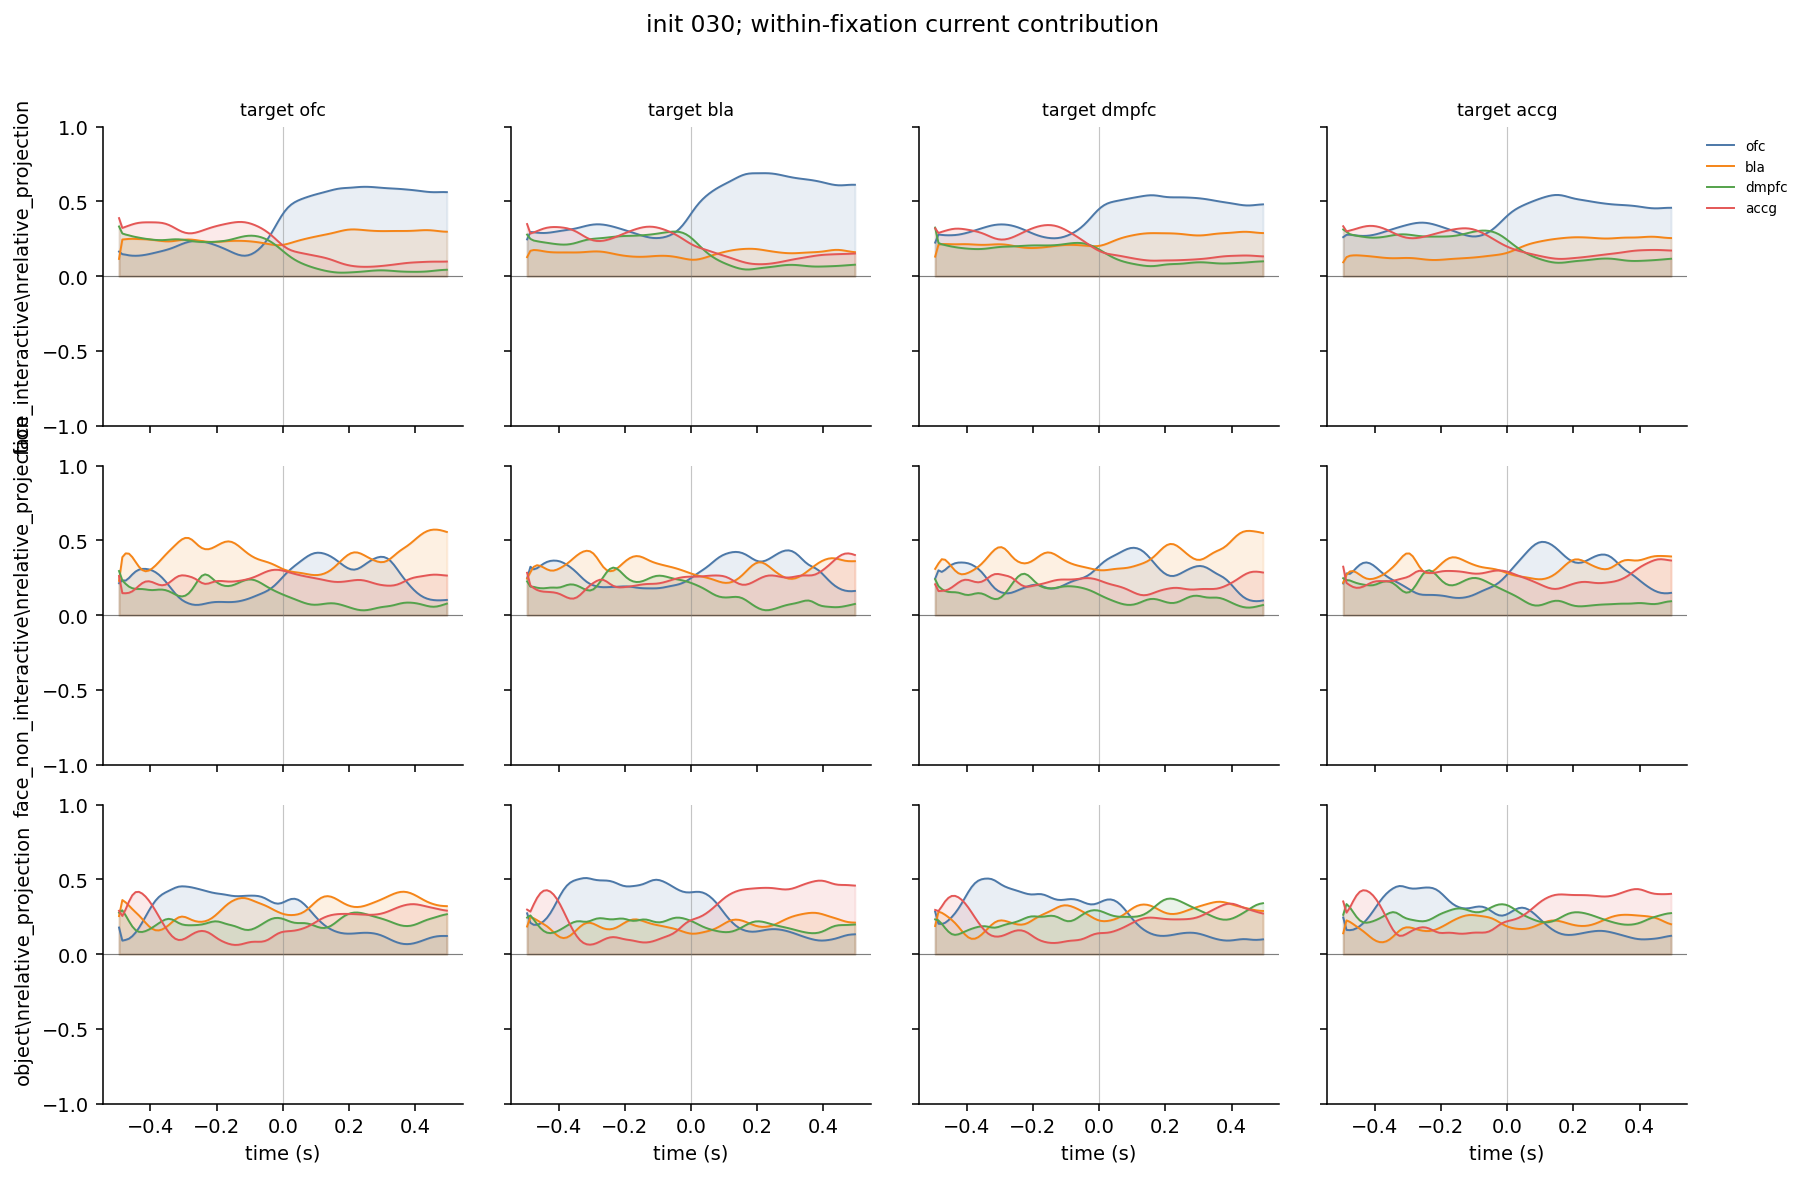

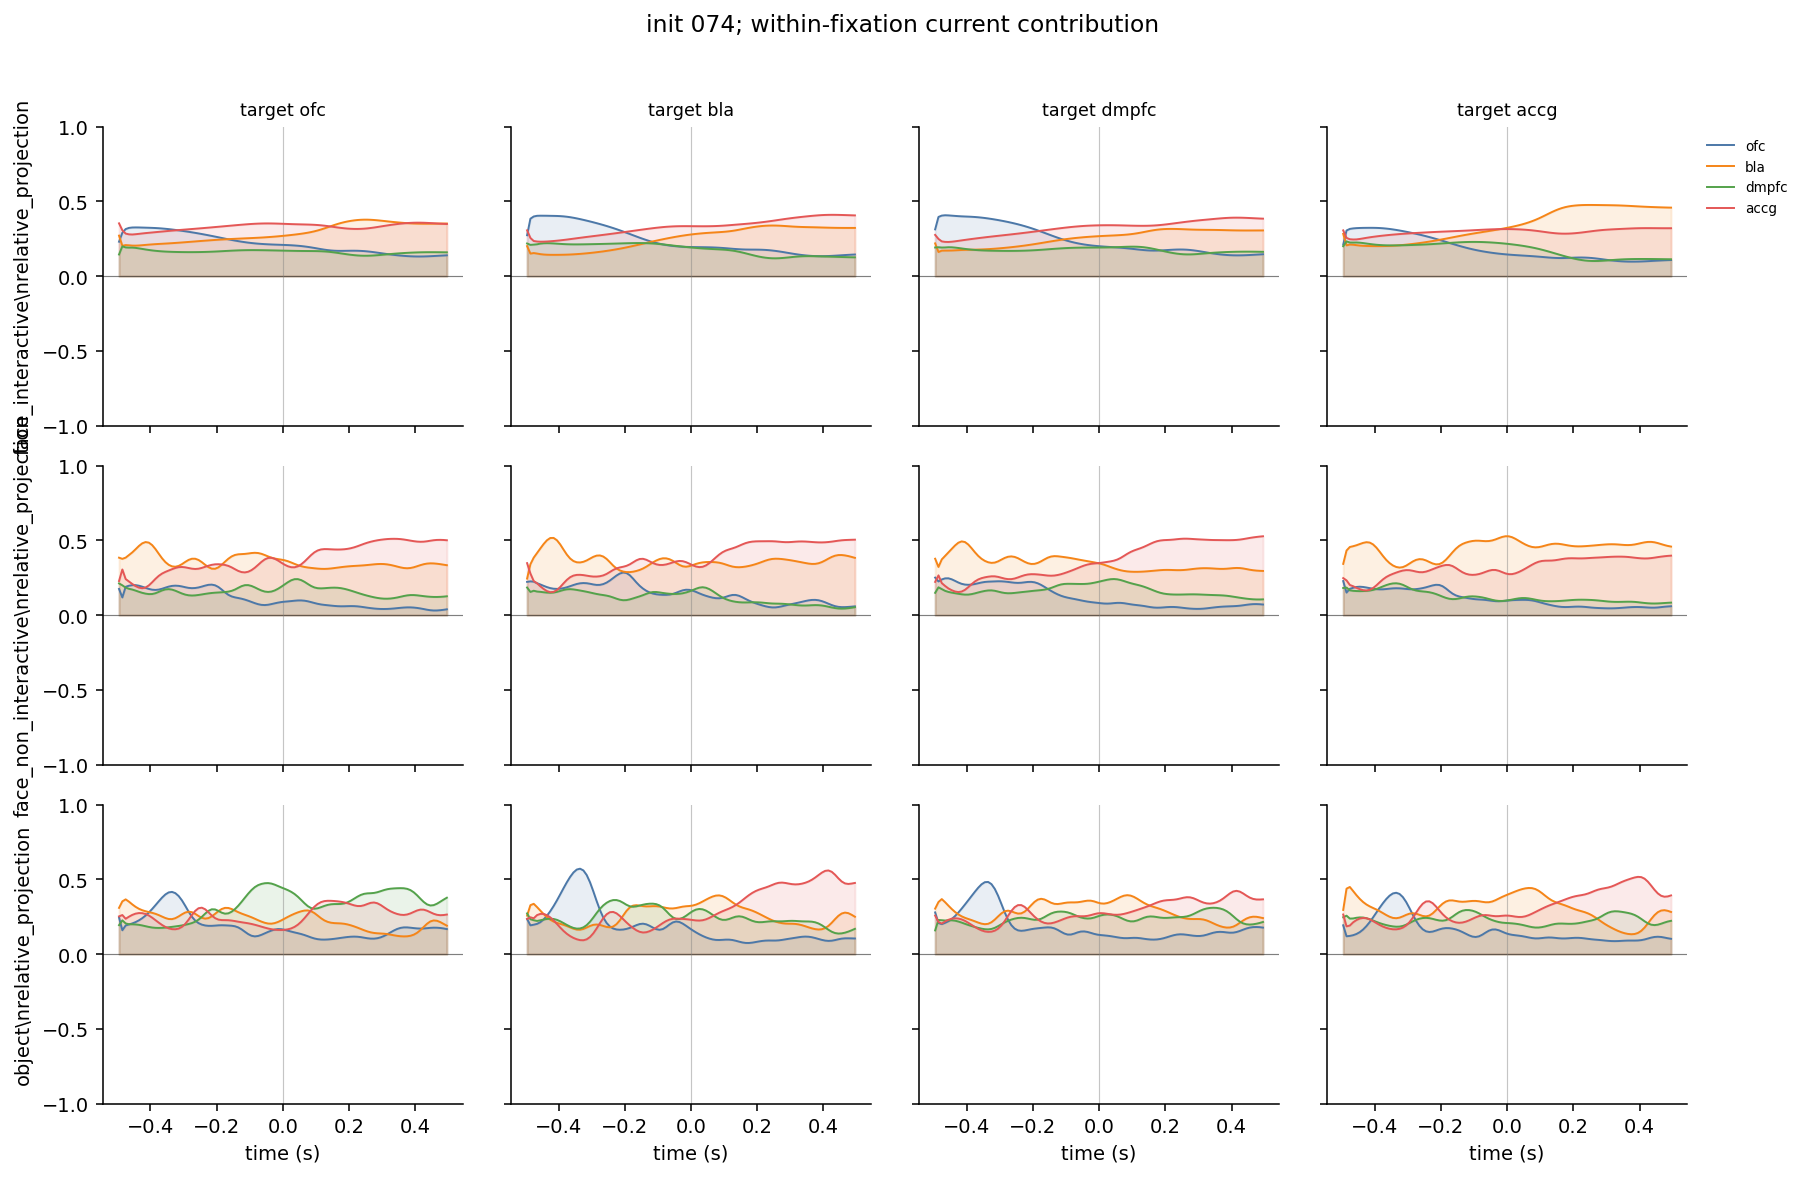

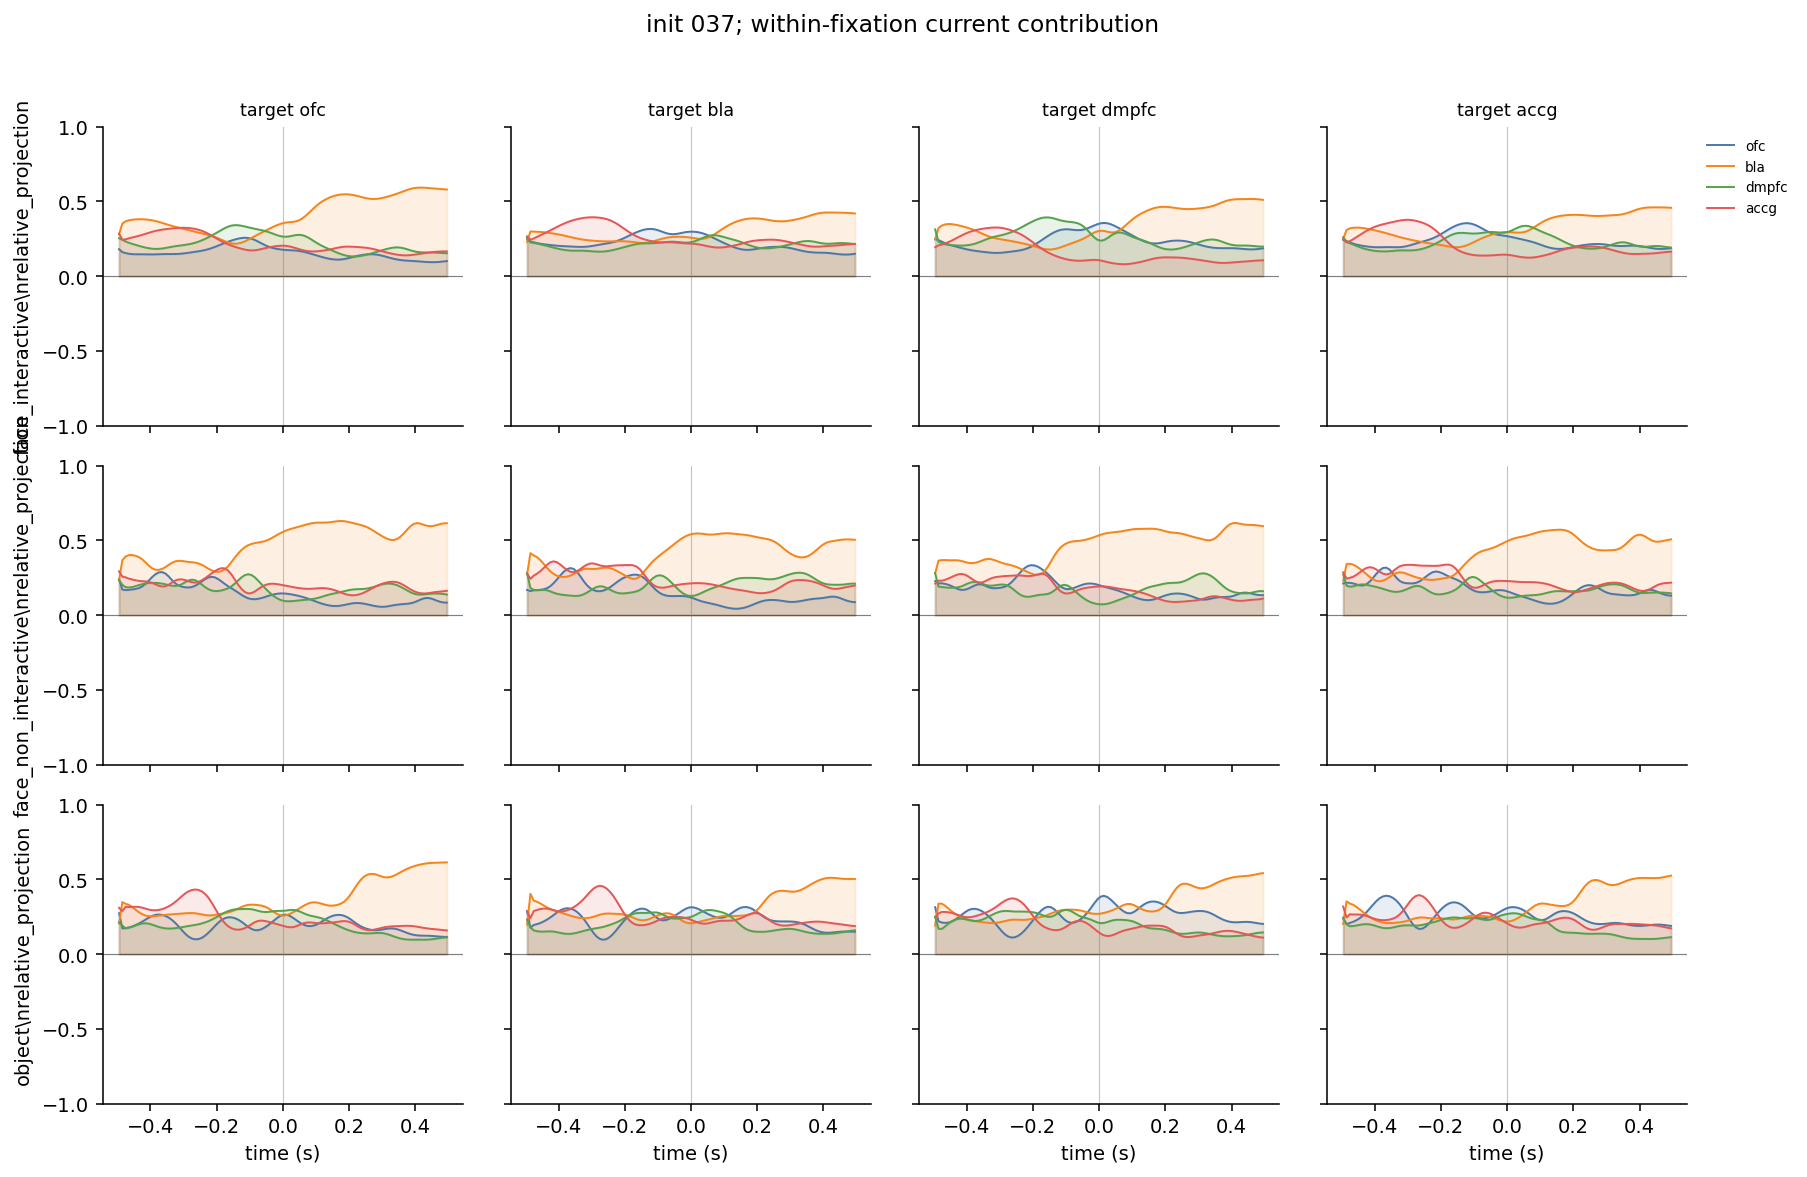

In [13]:
bottom3_within_projection = {}
for _, model_row in selected_bottom3.iterrows():
    fig, axes, df = plot_within_condition_source_contribution_for_model(model_row)
    bottom3_within_projection[int(model_row.init_idx)] = df

## 10. Save Available-Run and Selected-Model Summaries

In [14]:
summary_dir = ensemble_dir / "ensemble_summaries"
summary_dir.mkdir(parents=True, exist_ok=True)
run_table.to_csv(summary_dir / "run_table.csv", index=False)
model_rank.to_csv(summary_dir / "model_rank_transient_aware.csv", index=False)
all_history.to_pickle(summary_dir / "available_run_history.pkl")
top3_fit_quality.to_csv(summary_dir / "top3_fit_quality.csv", index=False)
bottom3_fit_quality.to_csv(summary_dir / "bottom3_fit_quality.csv", index=False)
for init_idx, df in top3_within_projection.items():
    df.to_pickle(summary_dir / f"top3_init_{init_idx:03d}_within_current_projection.pkl")
for init_idx, df in bottom3_within_projection.items():
    df.to_pickle(summary_dir / f"bottom3_init_{init_idx:03d}_within_current_projection.pkl")
print(summary_dir)

/gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/modeling/fixation_mrnn/scratch/ensemble_d5_c3_50u_100k_100init_clip1_div1e3/ensemble_summaries
